
# 用 Python 做贝叶斯建模与计算 —— 中文·现代库版

`原著: Osvaldo A. Martin, Ravin Kumar, Junpeng Lao`

`书名: Bayesian Modeling and Computation in Python (Chapman & Hall/CRC, 2021), ISBN 978-0-367-89436-8`

`中文翻译、库版本现代化 (PyMC 5 / ArviZ / TensorFlow Probability / NumPyro) 与内容增补: 本 fork 维护者`

___

本仓库 fork 自 [BayesianModelingandComputationInPython/BookCode_Edition1](https://github.com/BayesianModelingandComputationInPython/BookCode_Edition1)。
原仓库 README 明确写道:"This repository contains the open-access version of the
text and the code examples in the book",并以 **GPL-2.0** 协议开源全部文字与代码,
因此本翻译在保留原许可证、保留作者署名与引用信息的前提下进行。如果本书内容对你的工作
有帮助,请按照原仓库 README 中的 BibTeX 引用原书:

```
@book{BMCP2021,
  title = {{Bayesian Modeling and Computation in Python}},
  author = {Martin, Osvaldo A. and Kumar, Ravin and Lao, Junpeng},
  year = {2021},
  month = dec,
  address = {{Boca Raton}},
  isbn = {978-0-367-89436-8},
}
```

在原版基础上,本 fork 做了三件事:

1. **把每一章的代码迁移到当前版本的 PyMC(5.x)、ArviZ(<1,经典绘图 API)、TensorFlow
   Probability 与 NumPyro 上**,并逐章实际执行验证,确保端到端无报错。原仓库自带的
   `notebooks_updated/` 目录已经把代码升级到 PyMC 5.10 / ArviZ 0.17 一线,本翻译在此
   基础上继续适配到我们实际验证可用的库版本组合。
2. **把正文(`markdown/` 目录下的 MyST Markdown 书稿)全文翻译成中文**,不是逐字硬译,
   在原文过于精简的地方补充解释,并把原书的公式、脚注、边注(admonition)都保留下来。
3. **把正文与代码合并成一份自洽的 Jupyter Notebook**(原仓库的正文和代码是分开存放的:
   正文在 `markdown/chp_XX.md`,代码在 `notebooks_updated/chp_XX.ipynb`,二者通过图表/
   代码块编号相互引用)。这样中文读者可以在同一份文档里,边读解释边看代码边看运行结果。

每一章同时提供 Jupyter Notebook (`.ipynb`) 和 Org-mode (`.org`) 两种格式,内容保持同步。

**关于本地渲染环境的说明**:本章用到 `pm.model_to_graphviz()` 来绘制概率图模型的结构图,
这需要系统级的 Graphviz 可执行文件(`dot`)。原书图表以及部分数值结果依赖具体的随机种子、
库版本与采样器实现细节,重新执行后数字可能与纸质书上的图/表存在微小差异,但结论和数量级
是一致的。



# 第 1 章 贝叶斯推断
***

现代贝叶斯统计基本上都是通过计算机代码完成的。这与几十年前做贝叶斯统计的方式相比已经发生
了巨大变化:我们能够搭建的模型的复杂度提高了,而所需的数学和编程技能门槛降低了。此外,
"提出模型 → 拟合模型 → 检查模型 → 改进模型"这种迭代式建模过程,在很多方面也变得比以前
容易得多、也更贴近实际工作方式。强大计算方法的普及固然是件好事,但也对使用者提出了更高的
责任要求。即便表达统计方法变得比以往任何时候都容易,统计学依然是一个充满微妙之处的领域,
这些微妙之处不会因为用上了强大的计算工具就自动消失。因此,掌握良好的理论背景——尤其是那些
在实践中真正重要的理论——对有效运用统计方法而言,依然极为有用。在这第一章中,我们会介绍
这些概念与方法,其中很多会在全书后续章节中被进一步展开和拓展。



## 贝叶斯建模

一个概念模型(conceptual model)是对某个系统的表征,它由一系列概念组合而成,用来帮助
人们认识、理解或模拟该模型所代表的对象或过程。此外,模型是人为设计出来的表征,带有非常
具体的目的。正因如此,与其纠结于一个模型"内在是否正确",不如讨论它对给定问题是否"足够
恰当"更有意义。模型的存在,始终只是为了服务于某个更高层的目标。

比如汽车公司在设计新车时,会先做一个实物模型,帮助人们理解产品造出来之后大概是什么样子。
这时候,一位熟悉汽车、并且对模型将如何被使用有良好判断的雕塑师,会用粘土之类的原材料,借助
手工工具,把实物模型雕刻出来。这个实物模型可以帮助大家了解设计的方方面面,比如外观是否
美观,车身线条是否符合空气动力学。要做出有用的结果,需要将领域专业知识与雕塑技艺结合起来。
建模过程往往需要造出不止一个模型,或者是为了探索不同的方案,或者是因为模型需要随着与研发
团队其他成员的交流而不断迭代改进和扩展。如今除了实体汽车模型之外,通常还会有一个用计算机
辅助设计(CAD)软件搭建的数字模型。这种计算机模型相对实物模型有一些优势:用它做碰撞仿真
比用实车测试更简单、更便宜;也更容易与身处不同办公地点的同事分享。

这些同样的想法在贝叶斯建模中同样成立。搭建一个模型需要把领域专业知识与统计技能结合起来,
把知识转化为可计算的目标,并判断结果是否有用。数据是原材料,统计分布则是塑造统计模型的
主要数学工具。要做出有用的结果,同样需要领域专业知识和统计专业知识的结合。贝叶斯实践者
同样会以迭代的方式搭建不止一个模型,其中第一版模型主要是给建模者自己用的,用来发现自己
思路里的漏洞,或者模型本身的不足。这些最初的模型随后被用来搭建后续改进、扩展后的模型。
此外,使用某一种推断方式,并不会使其他方式变得没有用——就像一个实体车模不会让数字模型变得
没有用一样。同样地,现代贝叶斯实践者也有很多种方式来表达自己的想法、生成结果、分享输出,
从而让实践者及其同行都能获得更广泛的正面成果。

### 贝叶斯模型

不论是不是通过计算实现的,贝叶斯模型都有两个决定性特征:

- 未知量用概率分布来描述 [^1]。我们把这些量称为**参数(parameters)**[^2]。
- 用贝叶斯定理,依据数据来更新参数的取值。我们也可以把这个过程看作是概率的重新分配。

从高层次看,构建贝叶斯模型的过程可以概括为 3 个步骤:

1. 给定一些数据,以及关于这些数据是如何产生的一些假设,我们通过组合、变换随机变量,
   设计出一个模型。
2. 用贝叶斯定理,把模型与手头的数据关联起来。我们把这个过程称为**推断(inference)**,
   其结果是得到一个后验分布。我们希望数据能够降低参数可能取值的不确定性,但这并不是
   任何贝叶斯模型都能保证的事情。
3. 我们对模型进行批判性检查,依据数据以及我们对领域知识的了解,判断模型是否合理。因为
   我们通常对模型本身也存在不确定性,所以有时候还会比较多个模型。

如果你熟悉其他形式的建模,你会认识到"批判模型"的重要性,以及以迭代方式执行这 3 个步骤
的必要性。举例来说,我们可能需要在任何一个环节回退重来——也许是不小心引入了一个很蠢的
代码错误,也许是遇到一些挑战后找到了改进模型的方法,又或者发现数据并不像我们最初以为的
那样有用,需要收集更多数据,甚至是不同类型的数据。

本书会讨论如何执行这 3 个步骤的多种方式,并学习如何把它们拓展成更完整的**贝叶斯工作流
(Bayesian workflow)**。我们认为这个主题非常重要,专门用第 9 章来重新讨论这些想法。

### 贝叶斯推断

在口语中,"推断"通常与"依据证据和推理得出结论"相关联。贝叶斯推断是统计推断的一种特定
形式,它通过组合概率分布来得到其他概率分布。贝叶斯定理给出了一个通用的方法,用来在已经
观测到数据 $\boldsymbol{Y}$ 的条件下,估计参数 $\boldsymbol{\theta}$ 的取值:

$$
\underbrace{p(\boldsymbol{\theta} \mid \boldsymbol{Y})}_{\text{后验 posterior}} = \frac{\overbrace{p(\boldsymbol{Y} \mid \boldsymbol{\theta})}^{\text{似然 likelihood}}\; \overbrace{p(\boldsymbol{\theta})}^{\text{先验 prior}}}{\underbrace{{p(\boldsymbol{Y})}}_{\text{边际似然 marginal likelihood}}}
$$

似然函数把观测数据与未知参数联系起来,而先验分布则表示在观测到数据 $\boldsymbol{Y}$
**之前**,我们对参数存在的不确定性 [^3]。把二者相乘,就得到了后验分布,也就是模型中
所有参数(在给定观测数据条件下)的联合分布。下面这段代码复现了书中图 1.1 的思路:给定
一个任意的先验和似然,画出对应的后验 [^4]。

注意,虽然 $\boldsymbol{Y}$ 是观测数据,但它本身也是一个随机向量,因为它的取值依赖于
某次具体实验的结果 [^5]。为了得到后验分布,我们把数据当作固定在实际观测值上。正因如此,
一种常见的替代记号是用 $y_{obs}$ 来代替 $\boldsymbol{Y}$。

正如你所见,在某个具体的**点**上计算后验,概念上很简单——只需要把先验和似然相乘。但这
还不足以让我们了解后验的全貌,因为我们不仅需要知道后验在某一点的概率,还需要知道它相对
于周围点的概率。后验分布的这种**全局**信息,是由归一化常数所刻画的。不幸的是,计算归一化
常数 $p(\boldsymbol{Y})$ 本身就存在困难。如果把边际似然写成如下形式,这一点会更容易看出来:

$$
{p(\boldsymbol{Y}) = \int_{\boldsymbol{\Theta}} p(\boldsymbol{Y} \mid \boldsymbol{\theta})p(\boldsymbol{\theta}) d\boldsymbol{\theta}}
$$

其中 $\Theta$ 表示我们在对 $\theta$ 所有可能的取值进行积分。

计算这样的积分往往比乍看之下要困难得多(尤其是在意识到,对于绝大多数问题而言,压根不存在
闭式解的时候)。幸运的是,只要用得得当,有一些数值方法可以帮我们应对这一挑战。由于边际
似然通常无法算出来,贝叶斯定理很常见的一种写法是用"正比于"来表达:

$$
\underbrace{p(\boldsymbol{\theta} \mid \boldsymbol{Y})}_{\text{后验}} \propto \overbrace{p(\boldsymbol{Y} \mid \boldsymbol{\theta})}^{\text{似然}}\; \overbrace{p(\boldsymbol{\theta})}^{\text{先验}}
$$

> **关于记号的说明**:本书里我们用同一个记号 $p(\cdot)$ 来表示不同的量,比如似然函数
> 和先验概率分布。这在数学上略显不严谨,但我们发现这样做很有用。这种记号让所有这些量
> 拥有同样的"认识论地位"。此外,即便严格来说似然并不是一个概率密度函数,它反映出的事实
> 是:我们只在先验的语境下谈论似然,反之亦然——换句话说,我们把二者都看作是计算后验分布
> 时同样必不可少的模型组成部分。

贝叶斯统计有一个很好的特性:后验(永远)是一个分布。这让我们可以对参数做出概率性的表述,
比如"参数 $\boldsymbol{\tau}$ 为正的概率是 0.35",或者"$\boldsymbol{\phi}$ 最可能的取值
是 12,有 50% 的概率落在 10 到 15 之间"。更进一步,我们可以把后验分布看作是"模型 + 数据"
这一组合在逻辑上的必然结果,因此从后验推出的概率性表述在数学上是自洽的。但我们要记住,
这些漂亮的数学性质只在球体、高斯分布、马尔可夫链真实存在的"理念的柏拉图世界"里才成立。
一旦我们从数学的纯粹世界走进应用数学在*真实世界*中的杂乱现实,就必须始终牢记:我们的结果
不仅依赖于数据,也依赖于模型本身。因此,糟糕的数据和/或糟糕的模型可能导致荒谬的结论,即便
它们在数学上依然是自洽的。我们必须始终对自己的数据、模型和结果保持健康的怀疑态度。为了让
这一点更明确,我们可以把贝叶斯定理写成一种更细致的形式:

$$
p(\boldsymbol{\theta} \mid  \boldsymbol{Y}, M) \propto  p(\boldsymbol{Y} \mid \boldsymbol{\theta}, M) \; p(\boldsymbol{\theta}, M)
$$

这个写法强调了:我们的推断结果总是依赖于模型 $M$ 所做的假设。

有了后验分布之后,我们就可以用它推导出其他感兴趣的量,通常是通过计算期望来完成,例如:

$$
J = \int f(\boldsymbol{\theta}) \; p(\boldsymbol{\theta} \mid \boldsymbol{Y}) \; d\boldsymbol{\theta}
$$

如果 $f$ 是恒等函数,那么 $J$ 就是 $\boldsymbol{\theta}$ 的均值 [^7]:

$$
\bar{\boldsymbol{\theta}} = \int_{\boldsymbol{\Theta}} \boldsymbol{\theta}  p(\boldsymbol{\theta} \mid \boldsymbol{Y})  d\boldsymbol{\theta}
$$

后验分布是贝叶斯统计里的核心对象,但并不是唯一的对象。除了对参数取值做推断之外,我们
可能还想对**数据**本身做推断,这可以通过计算**先验预测分布(prior predictive
distribution)** 来实现:

$$
p(\boldsymbol{Y}^\ast) =  \int_{\boldsymbol{\Theta}} p(\boldsymbol{Y^\ast} \mid \boldsymbol{\theta}) \; p(\boldsymbol{\theta}) \; d\boldsymbol{\theta}
$$

这是根据模型(先验 + 似然)得到的、关于数据的**期望分布**。也就是说,在还没有观测到任何
真实数据 $\boldsymbol{Y}^\ast$ 之前,模型认为我们"应该"会看到的数据。注意,边际似然的
公式和先验预测分布的公式看起来非常相似,区别在于:前者是对我们已经观测到的数据 $Y$ 做
条件化,而后者没有对观测数据做条件化。因此边际似然是一个数字,而先验预测分布是一个概率
分布。

我们可以用先验预测分布的样本,结合领域知识来评估、校准我们的模型。举例来说,我们可以问
"一个关于人类身高的模型,预测出某人身高是 -1.5 米,这样合理吗?"——即便一个人都还没
量过,我们也能一眼看出这种预测的荒谬。本书后面会看到很多用先验预测分布来做模型评估的
具体例子,以及先验预测分布如何为后续建模决策的合理性提供依据。

> **贝叶斯模型即生成模型**:采用概率视角来建模,会引出一句箴言——"模型生成数据"
> (models generate data)。我们认为这个概念极为重要,一旦你把它内化,所有的统计模型
> ——甚至非贝叶斯模型——都会变得清晰很多。这句箴言也有助于我们创造新模型:如果模型生成
> 数据,那么我们只需要思考数据*可能*是如何被生成出来的,就可以为手头的数据构造出合适的
> 模型!而且这句箴言不仅仅是一个抽象概念,我们可以借助先验预测分布,把它落到具体、可
> 操作的层面。如果重新审视前面提到的贝叶斯建模 3 步骤,可以把它们重新表述为:写出一个
> 先验预测分布 → 加入数据来约束它 → 检查结果是否合理 → 如有必要就迭代。

另一个值得计算的量是**后验预测分布(posterior predictive distribution)**:

$$
p(\tilde{\boldsymbol{Y}} \mid \boldsymbol{Y}) = \int_{\boldsymbol{\Theta}} p(\tilde{\boldsymbol{Y}} \mid \boldsymbol{\theta}) \, p(\boldsymbol{\theta} \mid \boldsymbol{Y}) \, d\boldsymbol{\theta}
$$

这是根据后验分布 $p(\boldsymbol{\theta} \mid \boldsymbol{Y})$(它本身是模型与已观测数据
共同作用的结果),对**未来**数据 $\tilde{\boldsymbol{Y}}$ 给出的期望分布。用更通俗的话说,
这是模型在见过数据集 $\boldsymbol{Y}$ 之后,预期会观测到的数据——也就是模型的预测结果。
从公式中可以看出,预测是通过对参数的后验分布做积分(边缘化)得到的。因此,用这种方式算出
的预测,会自然而然地把我们对参数估计的不确定性也纳入其中。

> **用频率学派的眼光看待贝叶斯后验**:由于后验只是由模型和已观测数据推导出来的,我们
> 并没有对"未观测但有可能被观测到"的数据的实现做出任何论断——对未观测数据做推断,一般
> 是所谓频率学派方法的领地。然而,如果我们用后验预测样本来检查模型,那么我们实际上是
> (部分地)接受了频率学派"思考未观测但有可能被观测到的数据"这一理念。我们不仅不排斥
> 这个想法,本书中还会见到很多运用这一思路的例子。我们认为这是一个非常棒的想法——不妨
> 多多益善!


In [1]:
%matplotlib inline
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy import stats
from scipy.stats import entropy
from scipy.optimize import minimize


In [2]:
# 全书统一使用黑白灰(grayscale)绘图风格,与纸质书的印刷效果保持一致
az.style.use("arviz-grayscale")
plt.rcParams['figure.dpi'] = 300
np.random.seed(521)
# 三个自定义的"紫-绿-黄"配色,用于需要三种颜色区分曲线的图(例如不同先验)
viridish = [(0.2823529411764706, 0.11372549019607843, 0.43529411764705883, 1.0),
            (0.1450980392156863, 0.6705882352941176, 0.5098039215686274, 1.0),
            (0.6901960784313725, 0.8666666666666667, 0.1843137254901961, 1.0)]



**图 1.1** 下面这段代码演示了先验、似然与(未归一化的)后验之间的关系:用一个三角分布
(triangular distribution)作为先验,固定观测值 0.2 处的似然作为似然函数,二者相乘得到
后验。左图是原始概率密度尺度,右图是对数尺度——注意对数尺度保留了相对大小关系(比如
最大值、最小值的位置在两幅图里是一致的),而在数值计算中,对数尺度通常在数值上更稳定。


/tmp/ipykernel_1646367/3933215254.py:5: RuntimeWarning: divide by zero encountered in log
  log_prior = np.log(prior)


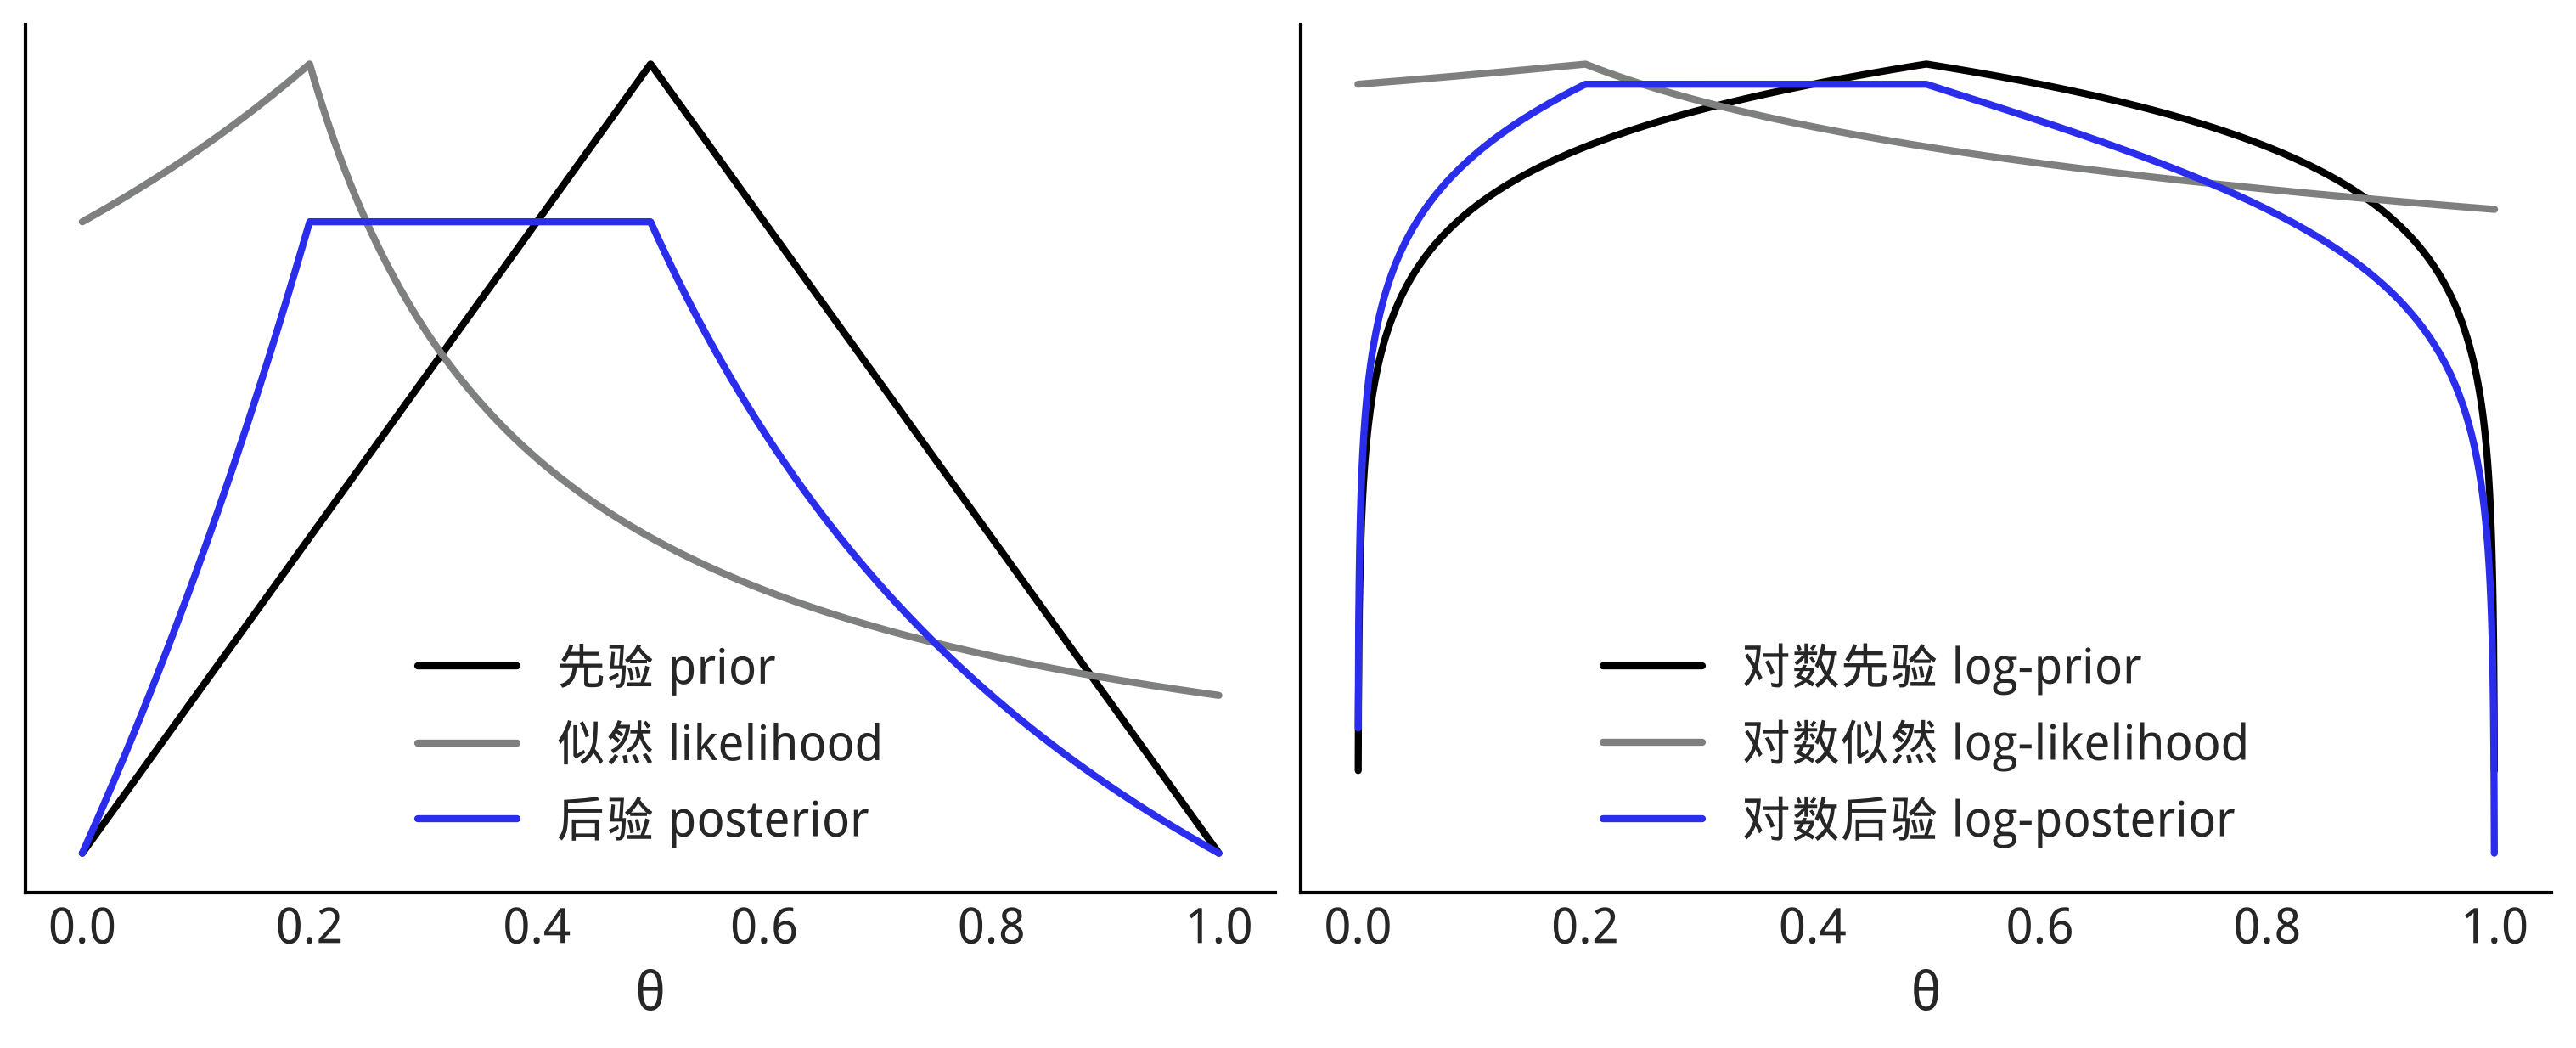

In [3]:
grid = np.linspace(0, 1, 5000)
prior = stats.triang.pdf(grid, 0.5)
likelihood = stats.triang.pdf(0.2, grid)
posterior = prior * likelihood
log_prior = np.log(prior)
log_likelihood = np.log(likelihood)
log_posterior = log_prior + log_likelihood


_, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(grid, prior, label="先验 prior", lw=2)
ax[0].plot(grid, likelihood, label="似然 likelihood", lw=2, color="C2")
ax[0].plot(grid, posterior, label="后验 posterior", lw=2, color="C4")
ax[0].set_xlabel("θ")
ax[0].legend()
ax[0].set_yticks([])


ax[1].plot(grid, log_prior, label="对数先验 log-prior", lw=2)
ax[1].plot(grid, log_likelihood, label="对数似然 log-likelihood", lw=2, color="C2")
ax[1].plot(grid, log_posterior, label="对数后验 log-posterior", lw=2, color="C4")
ax[1].set_xlabel("θ")
ax[1].legend()
ax[1].set_yticks([])
plt.savefig("img/chp01/bayesian_triad.png")



## 自己动手实现一个采样器,虽然并不建议在正式场合这么做

上面公式中边际似然那个积分,并不总是有闭式解,因此现代贝叶斯推断大多依赖数值方法,这类
方法有时被称为**通用推断引擎(Universal Inference Engines)**——起这么"宏大"的名字,多少
是想弥补一下我们生活在 21 世纪却依然没有飞行汽车的遗憾。好在已经有许多经过充分测试的
Python 库提供了这类数值方法,因此一般来说,贝叶斯实践者几乎不需要自己去实现一个通用推断
引擎。

时至今日,自己动手写推断引擎通常只有两个好理由:要么你在设计一个比现有引擎更好的新引擎,
要么你在学习现有引擎是如何工作的。既然本章是"学习"阶段,我们就来写一个;但本书剩下的
部分,我们都会使用 Python 库里现成的引擎。

可以用作"通用推断引擎"的算法有很多。其中被采用得最广泛、也最强大的一族方法是**马尔可夫
链蒙特卡洛(Markov chain Monte Carlo, MCMC)**方法。在很高的层面上说,所有 MCMC 方法都是
用**样本**来近似后验分布。这些来自后验分布的样本,是通过对另一个被称为"提议分布"
(proposal distribution)的分布进行采样,再按照一定规则接受或拒绝这些提议样本而生成的
[^8]。在满足一定假设、遵循特定规则的前提下,理论上可以保证我们最终得到的样本能够很好地
近似后验分布。因此,MCMC 方法也被称为采样器(samplers)。所有这些方法都要求我们能够在
给定参数值处计算先验和似然——也就是说,即便我们不知道整个后验长什么样,也可以逐点地
询问它的密度值。

其中一种算法就是 **Metropolis-Hastings** 算法 [^9]。这不是一种特别现代或特别高效的算法,
但它足够简单易懂,并且为理解更复杂、更强大的方法打下了基础。

Metropolis-Hastings 算法的定义如下:

1. 把参数 $\boldsymbol{X}$ 的取值初始化为 $x_i$
2. 用一个提议分布(有时在其他通用推断引擎里也被称为"核",kernel)[^10]
   $q(x_{i + 1} \mid x_i)$,根据旧值 $x_i$ 生成一个新值 $x_{i + 1}$。
3. 计算接受新值的概率:

$$
p_a (x_{i + 1} \mid x_i) = \min \left (1, \frac{p(x_{i + 1}) \;
q(x_i \mid x_{i + 1})} {p(x_i) \; q (x_{i + 1} \mid x_i)} \right)
$$

4. 如果 $p_a > R$,其中 $R \sim \mathcal{U}(0, 1)$,就保留新值,否则保留旧值。
5. 重复步骤 2~4,直到生成了**足够多**的样本。

Metropolis 算法非常通用,也可以用在非贝叶斯场景中,但就本书关心的场景而言,$p(x_i)$
是后验密度在参数值 $x_i$ 处的取值。注意,如果 $q$ 是一个对称分布,那么
$q(x_i \mid x_{i + 1})$ 和 $q(x_{i + 1} \mid x_i)$ 这两项会相互抵消(概念上讲,这意味着
从 $x_{i+1}$ 走到 $x_i$,和从 $x_{i}$ 走到 $x_{i+1}$ 的"可能性"是一样的),只剩下后验在
两点处取值的比值。从接受概率的公式可以看出,这个算法**总是**会接受从低概率区域移动到
高概率区域的提议,而从高概率区域移动到低概率区域的提议则**以一定概率**被接受。

还有一点很重要:Metropolis-Hastings 算法**不是**一种优化方法!我们并不关心找到概率最大
的那个参数值,我们想要**探索**整个后验分布 $p$。这一点从算法本身就能看出来:即便已经走到
了概率最大的地方,后续步骤中算法仍然可能移动到概率更低的区域。

为了让这一切更具体,我们来试着求解 Beta-Binomial 模型。这大概是贝叶斯统计里最常见的例子
了,用来对二元、互斥的结果建模,比如 0 或 1、阳性或阴性、正面或反面、垃圾邮件或正常邮件、
是热狗还是不是热狗、健康还是不健康,等等。Beta-Binomial 模型常常被用作介绍贝叶斯统计
基础知识的第一个例子,因为它是一个简单、可以轻松求解和计算的模型。用统计记号写出来就是:

$$
\begin{split}
    \theta \sim &\; \text{Beta}(\alpha, \beta) \\
    Y \sim &\; \text{Bin}(n=1, p=\theta)
\end{split}
$$

上式说的是,参数 $\theta$ 的先验分布是 $\text{Beta}(\alpha, \beta)$,并且我们假设数据服从
二项分布 $\text{Bin}(n=1, p=\theta)$,也就是我们的似然分布。在这个模型里,"成功次数"
$\theta$ 可以代表诸如"正面朝上的比例"或者"患者死亡的比例"这类量——有时候统计学确实可以
是个挺阴暗的地方。这个模型有解析解(见下文"共轭先验"一节的讨论),但为了举例说明,
我们先假装不知道该怎么求后验的解析解,于是用 Python 实现 Metropolis-Hastings 算法来得到
一个近似解。我们会借助 SciPy 的统计函数来实现:


In [4]:
def post(θ, Y, α=1, β=1):
    if 0 <= θ <= 1:
        # 先验密度 × 似然(把 20 个伯努利观测的概率连乘起来)
        prior = stats.beta(α, β).pdf(θ)
        like  = stats.bernoulli(θ).pmf(Y).prod()
        prop = like * prior
    else:
        # θ 落在 [0,1] 之外是不合法的,给一个 -inf 使其必然被拒绝
        prop = -np.inf
    return prop



接下来我们还需要数据,于是生成一些用于本例的随机模拟数据:


In [5]:
Y = stats.bernoulli(0.7).rvs(20)



最后,运行我们自己实现的 Metropolis-Hastings 算法:


In [6]:
n_iters = 1000
can_sd = 0.05  # 提议分布(正态分布)的标准差,这是采样器自身的调优参数,不是模型参数
α = β = 1
θ = 0.5
trace = {'θ': np.zeros(n_iters)}
p2 = post(θ, Y, α, β)

for iter in range(n_iters):
    # 从以当前 θ 为中心、can_sd 为标准差的正态分布中生成一个候选值 θ_can
    # 注意:.rvs(1) 返回的是形状 (1,) 的数组,取 [0] 得到标量,
    # 否则后面 trace['θ'][iter] = θ 在较新版本 numpy 下会因为
    # "无法把长度为 1 的数组隐式转换成标量" 而报错(这是原书代码在旧版 numpy
    # 下可以运行、但在新版 numpy 下会报错的一处典型改动)
    θ_can = stats.norm(θ, can_sd).rvs(1)[0]
    p1 = post(θ_can, Y, α, β)
    # 接受概率:候选点后验 / 当前点后验(提议分布对称,所以这两项直接相消)
    pa = p1 / p2

    if pa > stats.uniform(0, 1).rvs(1):
        θ = θ_can
        p2 = p1

    # 无论是否接受新值,都把"当前"值记录进 trace(拒绝时就是重复上一步的值)
    trace['θ'][iter] = θ



在上面这段代码里:我们用 `can_sd` 为标准差的正态分布生成候选提议值 `θ_can`;然后在这个新
生成的值处计算后验 `p1`,并据此算出接受概率 `pa`;`trace` 数组里保存的是 `θ` 的值——不管
这一步是接受了新值还是重复了上一步的旧值,这都取决于前面的比较结果。

回到我们的例子,现在有了 MCMC 样本,我们想知道它*长什么样*。检查贝叶斯推断结果的一种常见
做法,是把每次迭代采样得到的值画出来,再配上一个直方图或者其他可视化工具来表示分布。我们
先用 ArviZ 计算一些数值汇总统计量:


In [7]:
az.summary(trace, kind='stats', round_to=2)


,mean,sd,hdi_3%,hdi_97%
θ,0.69,0.1,0.51,0.87



ArviZ 的 `summary` 函数计算了参数 $\theta$ 的均值、标准差以及 94% 最高密度区间(Highest
Density Interval, HDI)。HDI 是包含给定比例(此处是 94%)概率密度的最短区间 [^12]。下面
这幅图,用 `az.plot_posterior(trace)` 生成,可以看作是上面数值汇总的可视化版本:我们能
看到均值和 HDI,叠加在代表整个后验分布的曲线上。这条曲线是用**核密度估计
(kernel density estimator, KDE)**计算出来的,可以把它理解成"平滑版的直方图"。ArviZ
在很多绘图函数里都用到了 KDE,甚至在一些内部计算里也会用到。

HDI 在贝叶斯统计里是很常见的选择,50% 或 95% 这样"整齐"的数值也很常见。但 ArviZ 默认用
94%(即 0.94)作为汇总统计和绘图的默认值,原因是:94 和常用的 95 很接近,但又刻意不同,
提醒我们这些"整齐"的数值本身并没有什么特别之处。理想情况下你应该选择一个符合自身需求的
数值,或者至少承认自己用的是一个默认值。

我们也把左右两幅图画出来:左边是每次迭代采样得到的 $\theta$ 值,右边是这些采样值的直方图
(旋转过来,方便和左图对照着看,直观感受到二者其实是同一份数据的两种呈现方式)。左图展示
的是采样值的*序列*——这正是我们的马尔可夫链;右图则展示了这些采样值的分布。


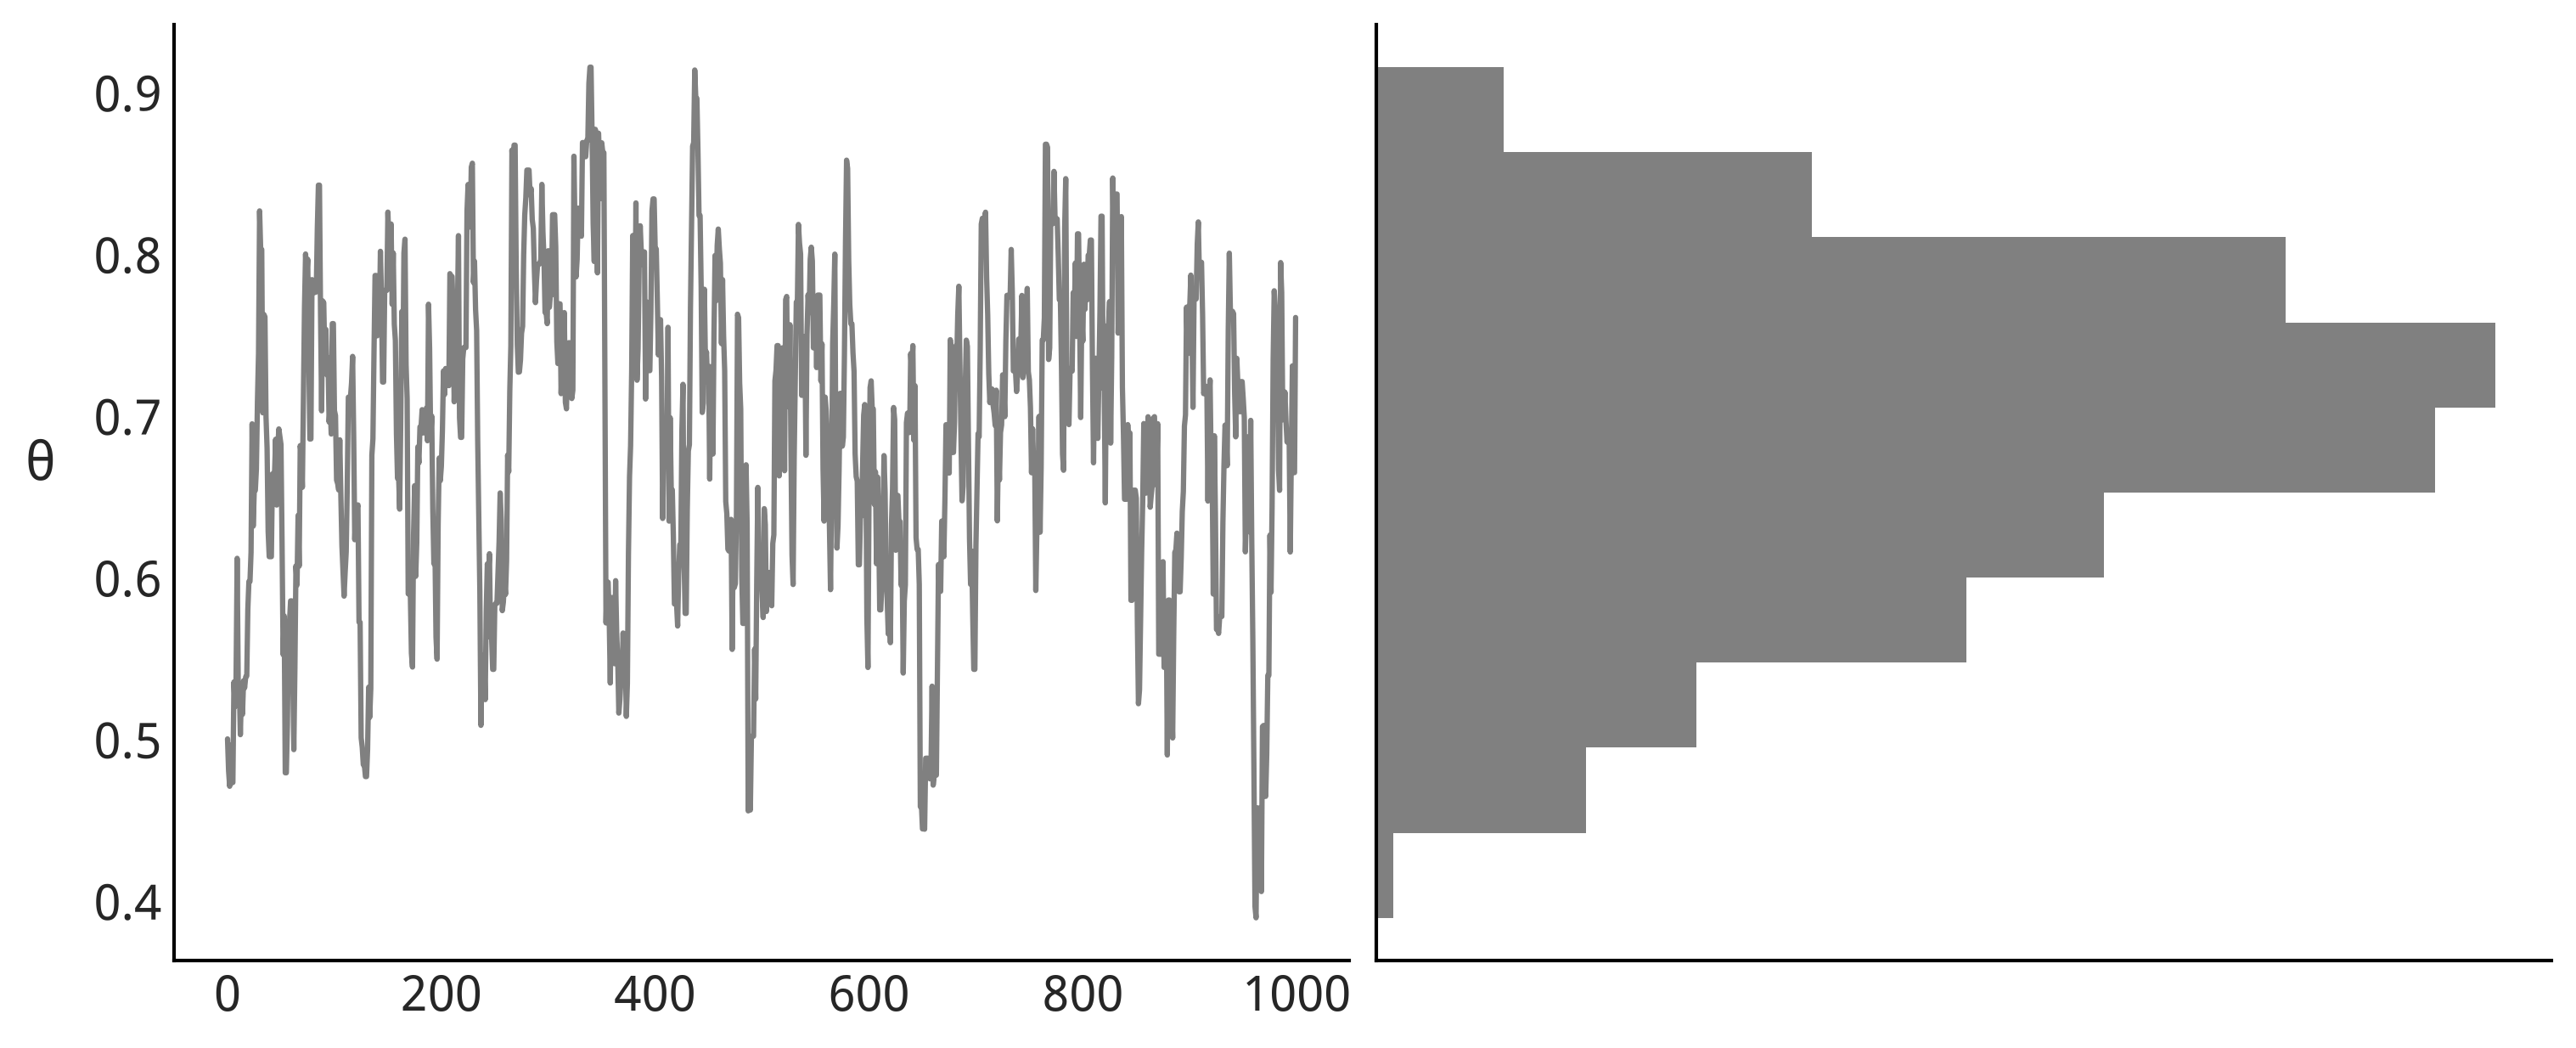

In [8]:
_, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)
axes[1].hist(trace['θ'], color='0.5', orientation="horizontal", density=True)
axes[1].set_xticks([])
axes[0].plot(trace['θ'], '0.5')
axes[0].set_ylabel('θ', rotation=0, labelpad=15)
plt.savefig("img/chp01/traceplot.png")



## 拥抱自动化推断,但不要自动化建模本身

除了自己写采样器、用 `scipy.stats` 定义模型之外,我们还可以借助**概率编程语言
(Probabilistic Programming Languages, PPL)**。这类工具让用户可以用代码表达贝叶斯模型,
再借助通用推断引擎,以相当自动化的方式完成贝叶斯推断。简而言之,PPL 帮助实践者把更多精力
放在建模本身,少花精力在数学和计算细节上。这类工具的出现,是过去几十年贝叶斯方法愈发流行
和实用的重要推手。不过,这些所谓的"通用推断引擎"其实并没有那么"通用"——它们并不能高效
求解每一个贝叶斯模型(但我们还是很喜欢这个炫酷的名字!)。理解并绕开这些局限,正是现代
贝叶斯实践者工作的一部分。

本书中我们会使用 PyMC(原文写作 PyMC3,现已演进为 PyMC 5/6)以及 TensorFlow Probability。
下面我们用 PyMC 把 Beta-Binomial 模型重新写一遍:


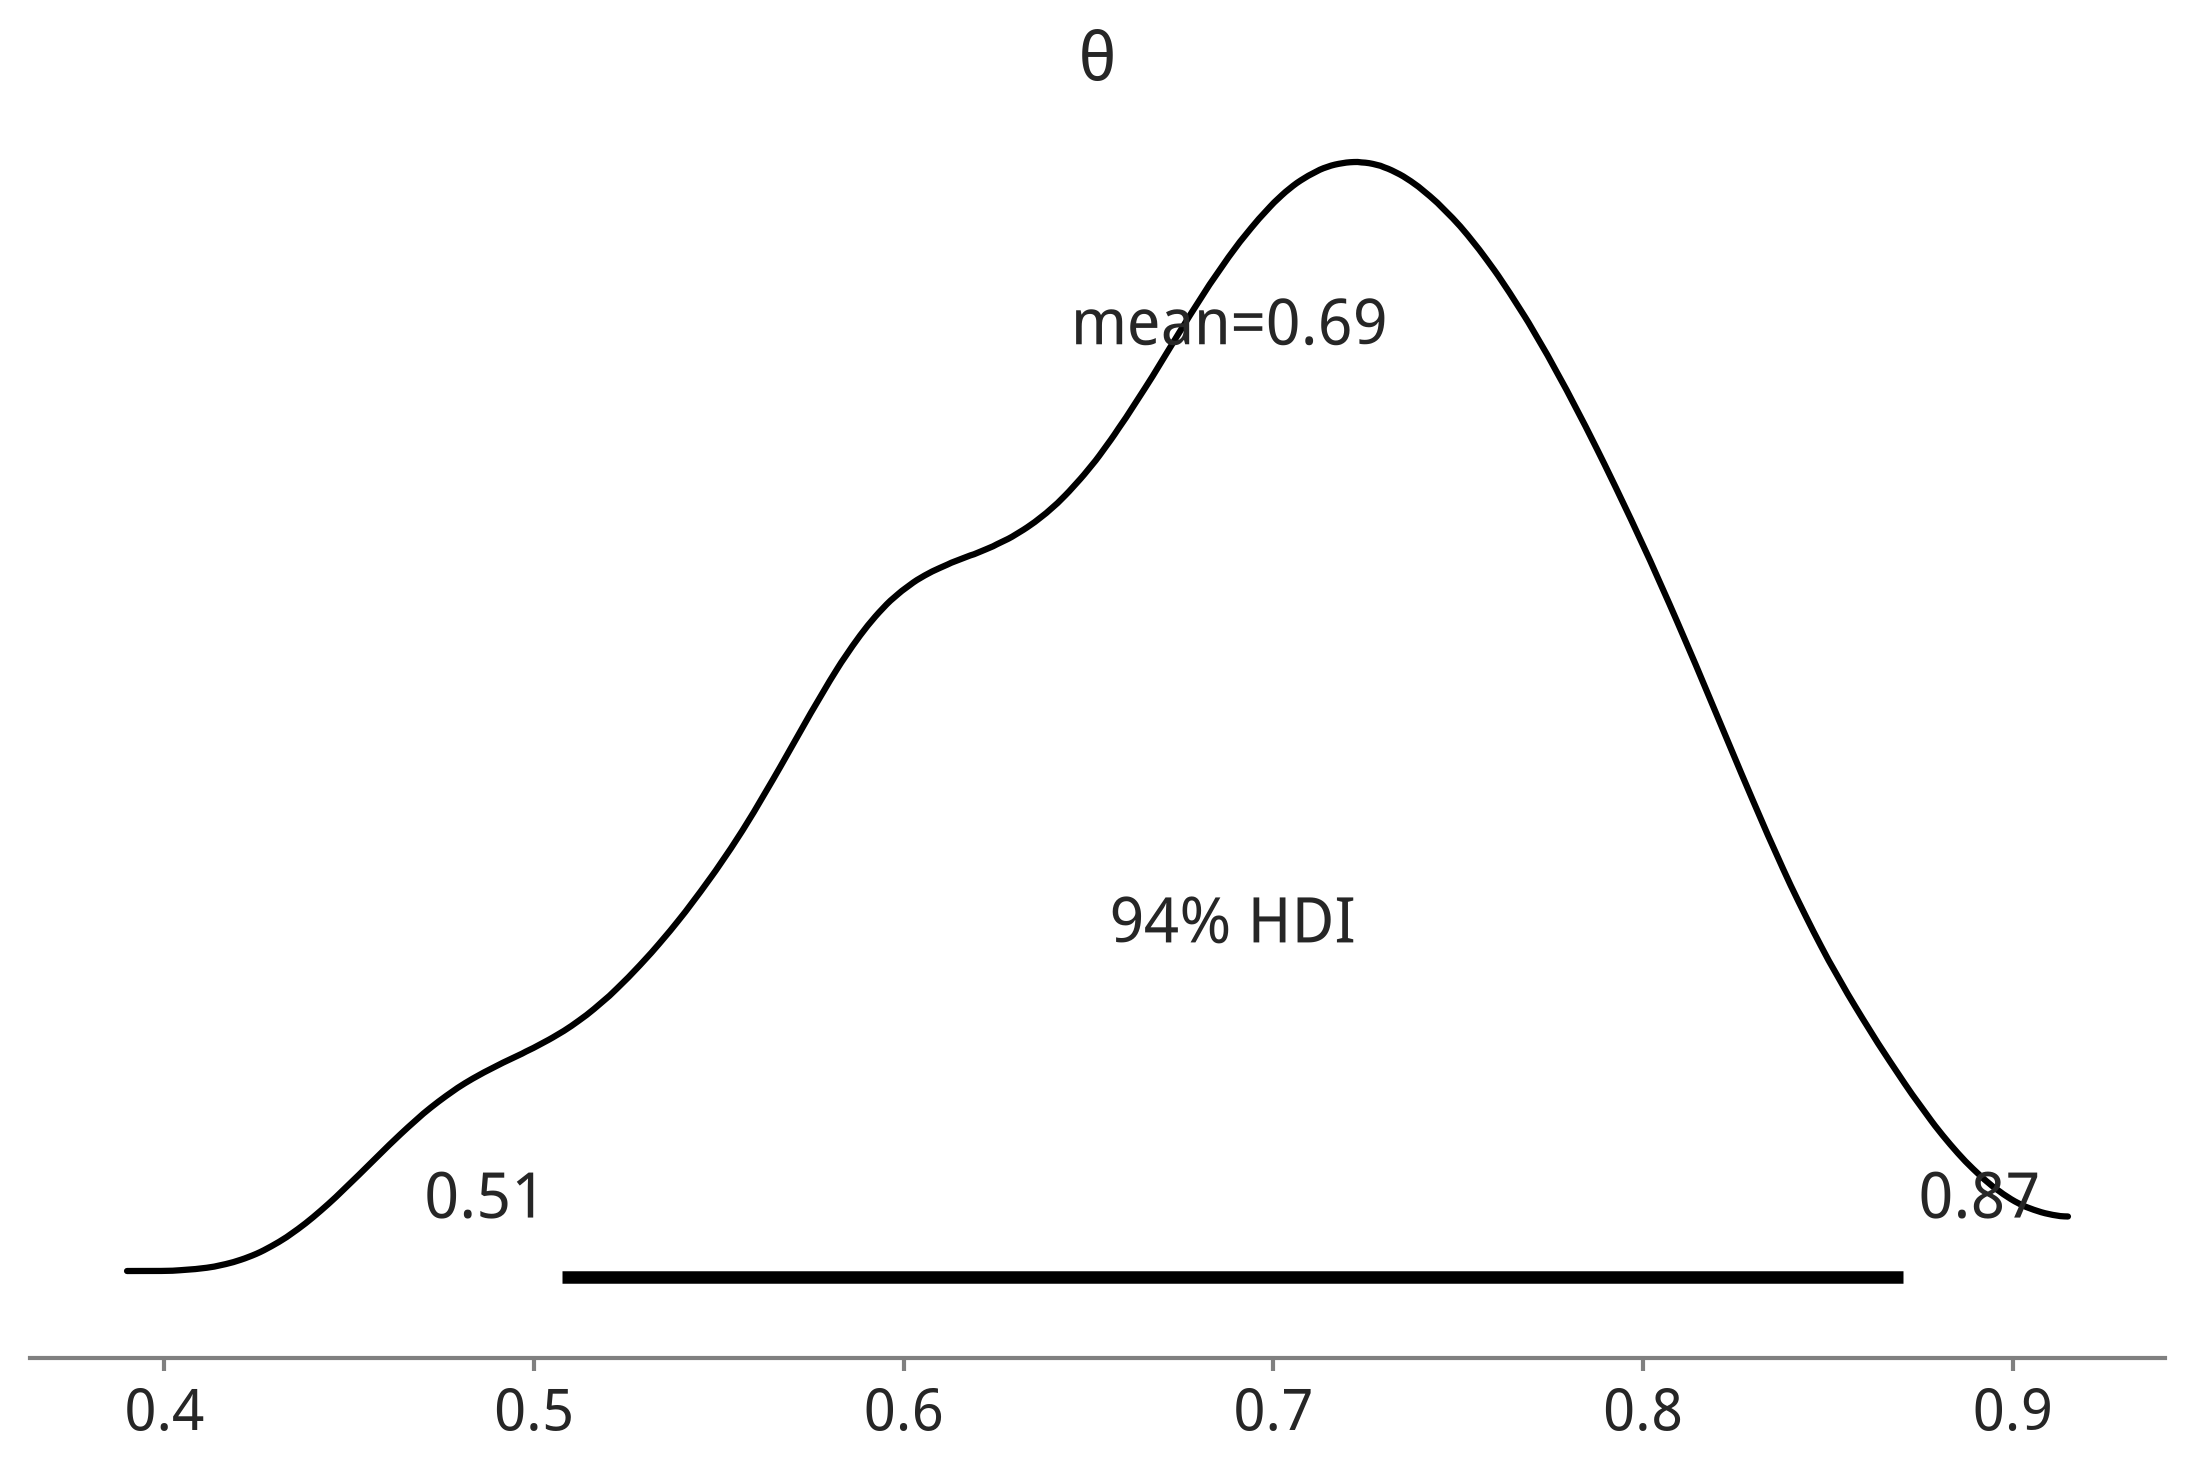

In [9]:
az.plot_posterior(trace)
plt.savefig("img/chp01/plot_posterior.png")


In [10]:
# 用 PyMC 声明模型
with pm.Model() as model:
    # 指定未知参数 θ 的先验分布
    θ = pm.Beta("θ", alpha=1, beta=1)

    # 指定似然分布,并用观测数据 Y 对其做条件化
    y_obs = pm.Binomial("y_obs", n=1, p=θ, observed=Y)

    # 从后验分布中采样
    # 注意:PyMC 5.x 起 pm.sample() 默认直接返回 arviz.InferenceData,
    # 不再需要像 PyMC3 时代那样显式传入 return_inferencedata=True
    idata = pm.sample(1000)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [θ]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics



你可以自己验证一下,这段代码给出的结果,和我们前面手写的 DIY 采样器基本一致,但省力得多。
如果你还不熟悉 PyMC 的语法,现在只需要关注每一行代码的**意图**,代码里的注释已经写清楚了。

由于我们已经用 PyMC 语法定义好了模型,还可以用 `pm.model_to_graphviz(model)` 来生成模型
的图形化表示:


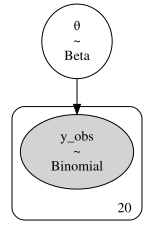

In [11]:
graphviz = pm.model_to_graphviz(model)
graphviz


In [12]:
graphviz.graph_attr.update(dpi="300")
graphviz.render("img/chp01/BetaBinomModelGraphViz", format="png")


'img/chp01/BetaBinomModelGraphViz.png'


图中的椭圆分别代表我们的先验和似然,而 20 则表示观测数据的个数。

> **用多种方式表达模型**:表达一个统计模型的架构,有很多种方法,不分先后包括:
> - 口头或书面语言
> - 概念性的示意图(比如上面刚生成的图模型)
> - 数学记号(比如 Beta-Binomial 模型的公式)
> - 计算机代码(比如上面 `pm.Model()` 那段代码)
>
> 对现代贝叶斯实践者来说,能够在这些不同"语言"之间自如切换非常有用。你会在讲座、论文、
> 和同事讨论时的手绘草图、网上的代码示例等各种场合遇到这些不同的表达形式。熟练掌握这些
> 不同媒介,能让你更好地理解一种形式呈现的概念,再用另一种形式把它表达出来——比如读完
> 一篇论文后把模型实现出来,或者在讲座上听到一个技巧后写成一篇博客。对个人而言,这种
> 多语言的流利程度会加快你的学习速度,也能提升你与他人交流的能力。这最终有助于实现整个
> 统计学界一直以来所追求的目标——对世界形成更好的共同理解。

概率编程语言不仅能对随机变量的对数概率求值来得到后验分布,还可以从各种分布中做正向模拟。
比如下面这段代码,展示了如何用 PyMC 分别从**先验预测分布**和**后验预测分布**中各生成
1000 个样本。注意第一个函数只需要传入 `model` 作为参数,而第二个函数需要同时传入 `model`
和后验采样结果 `idata`——这反映了一个事实:先验预测分布只需要模型本身就能算出来,而后验
预测分布则需要模型加上后验。生成的先验/后验预测分布样本,分别对应下图的第一和第三个子图。


In [13]:
pred_dists = (pm.sample_prior_predictive(1000, model).prior_predictive["y_obs"].values,
              pm.sample_posterior_predictive(idata, model).posterior_predictive["y_obs"].values)


Sampling: [y_obs, θ]


Sampling: [y_obs]


Output()


后验、先验预测和后验预测分布这三个公式,清楚地把后验、先验预测分布、后验预测分布定义为
三种不同的数学对象:后两者是关于**数据**的分布,而第一个是模型中**参数**的分布。下图帮助
我们直观地看到这种区别,并且为了完整性,也把先验分布本身画了出来。


findfont: Failed to find font weight bold, now using 400.


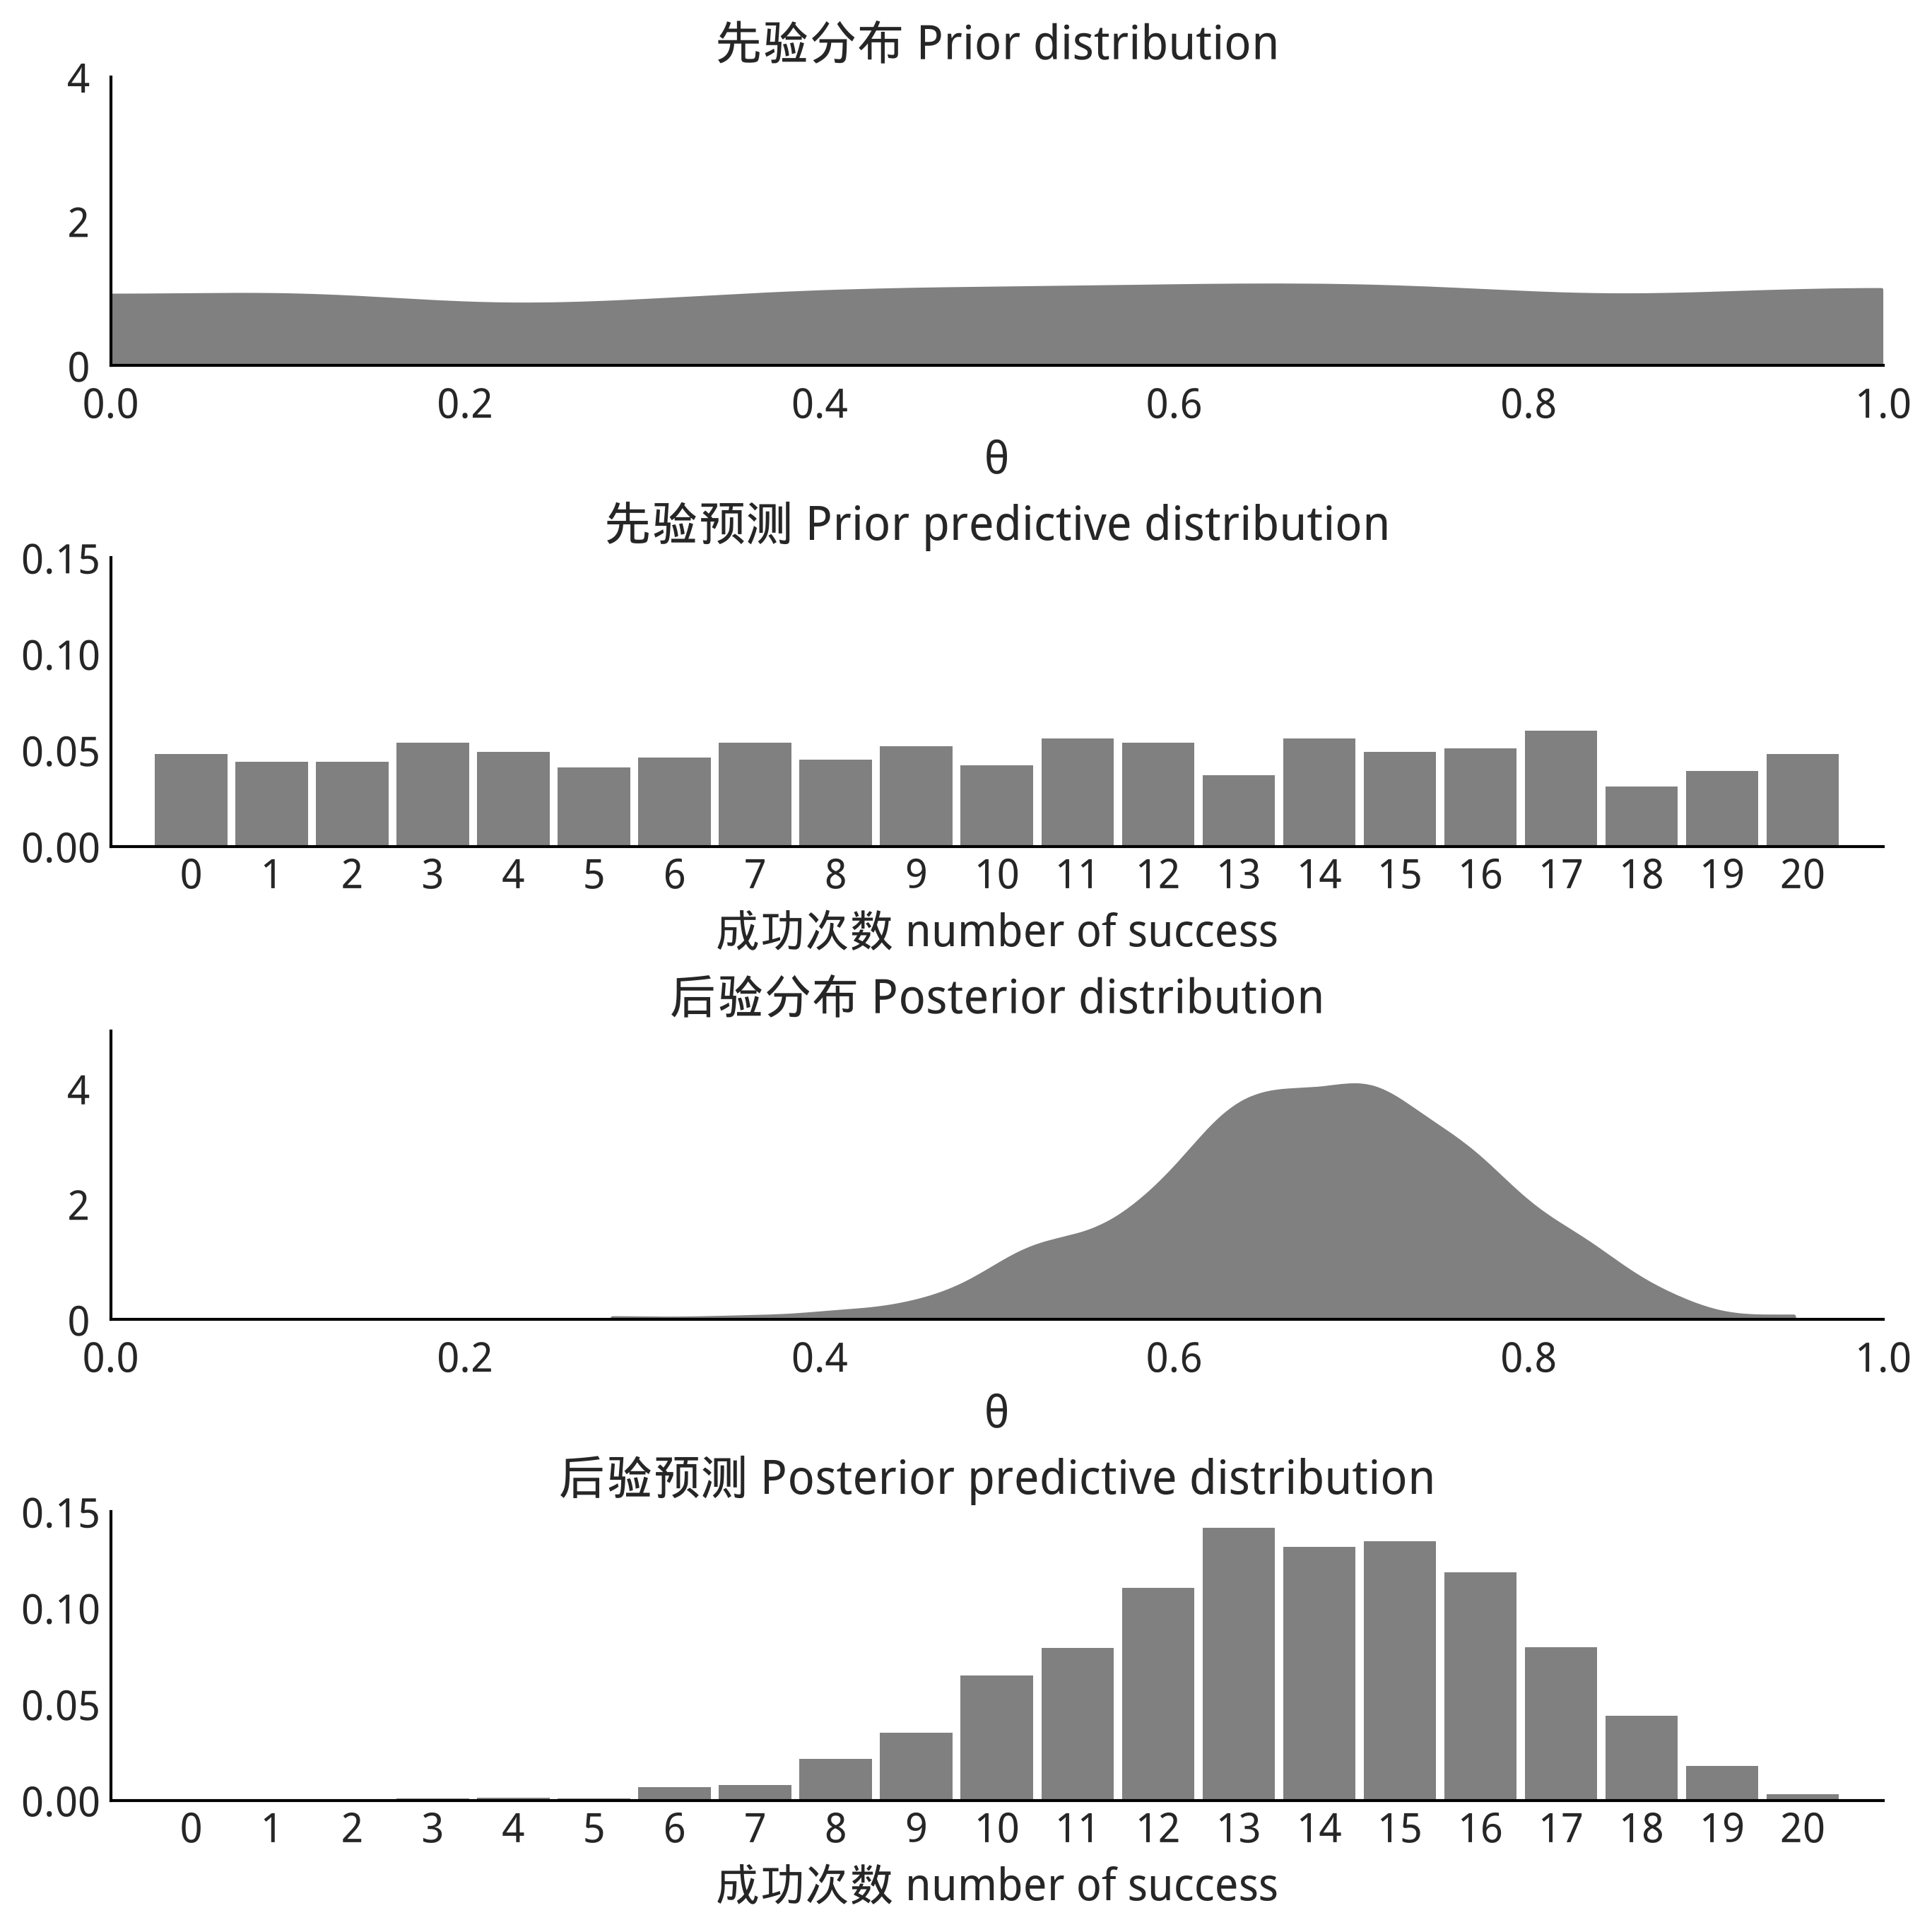

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(9, 9))

for idx, n_d, dist in zip((1, 3), ("先验预测 Prior", "后验预测 Posterior"), pred_dists):
    az.plot_dist(dist.sum(-1),
                 hist_kwargs={"color": "0.5", "bins": range(0, 22)},
                 ax=axes[idx])
    axes[idx].set_title(f"{n_d} predictive distribution", fontweight='bold')
    axes[idx].set_xlim(-1, 21)
    axes[idx].set_ylim(0, 0.15)
    axes[idx].set_xlabel("成功次数 number of success")

az.plot_dist(pm.draw(θ, 1000), plot_kwargs={"color": "0.5"},
             fill_kwargs={'alpha': 1}, ax=axes[0])
axes[0].set_title("先验分布 Prior distribution", fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 4)
axes[0].tick_params(axis='both', pad=7)
axes[0].set_xlabel("θ")

az.plot_dist(idata.posterior["θ"], plot_kwargs={"color": "0.5"},
             fill_kwargs={'alpha': 1}, ax=axes[2])
axes[2].set_title("后验分布 Posterior distribution", fontweight='bold')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 5)
axes[2].tick_params(axis='both', pad=7)
axes[2].set_xlabel("θ")

plt.savefig("img/chp01/Bayesian_quartet_distributions.png")



前面已经提到,后验预测分布把我们对参数估计的不确定性也纳入了考虑。下图显示,用后验**均值**
做出的预测,要比用整个后验预测分布做出的预测更"集中"(方差更小)。这个结论并非只对均值
成立——如果把均值换成任何其他的点估计,也会得到类似的结果图景。


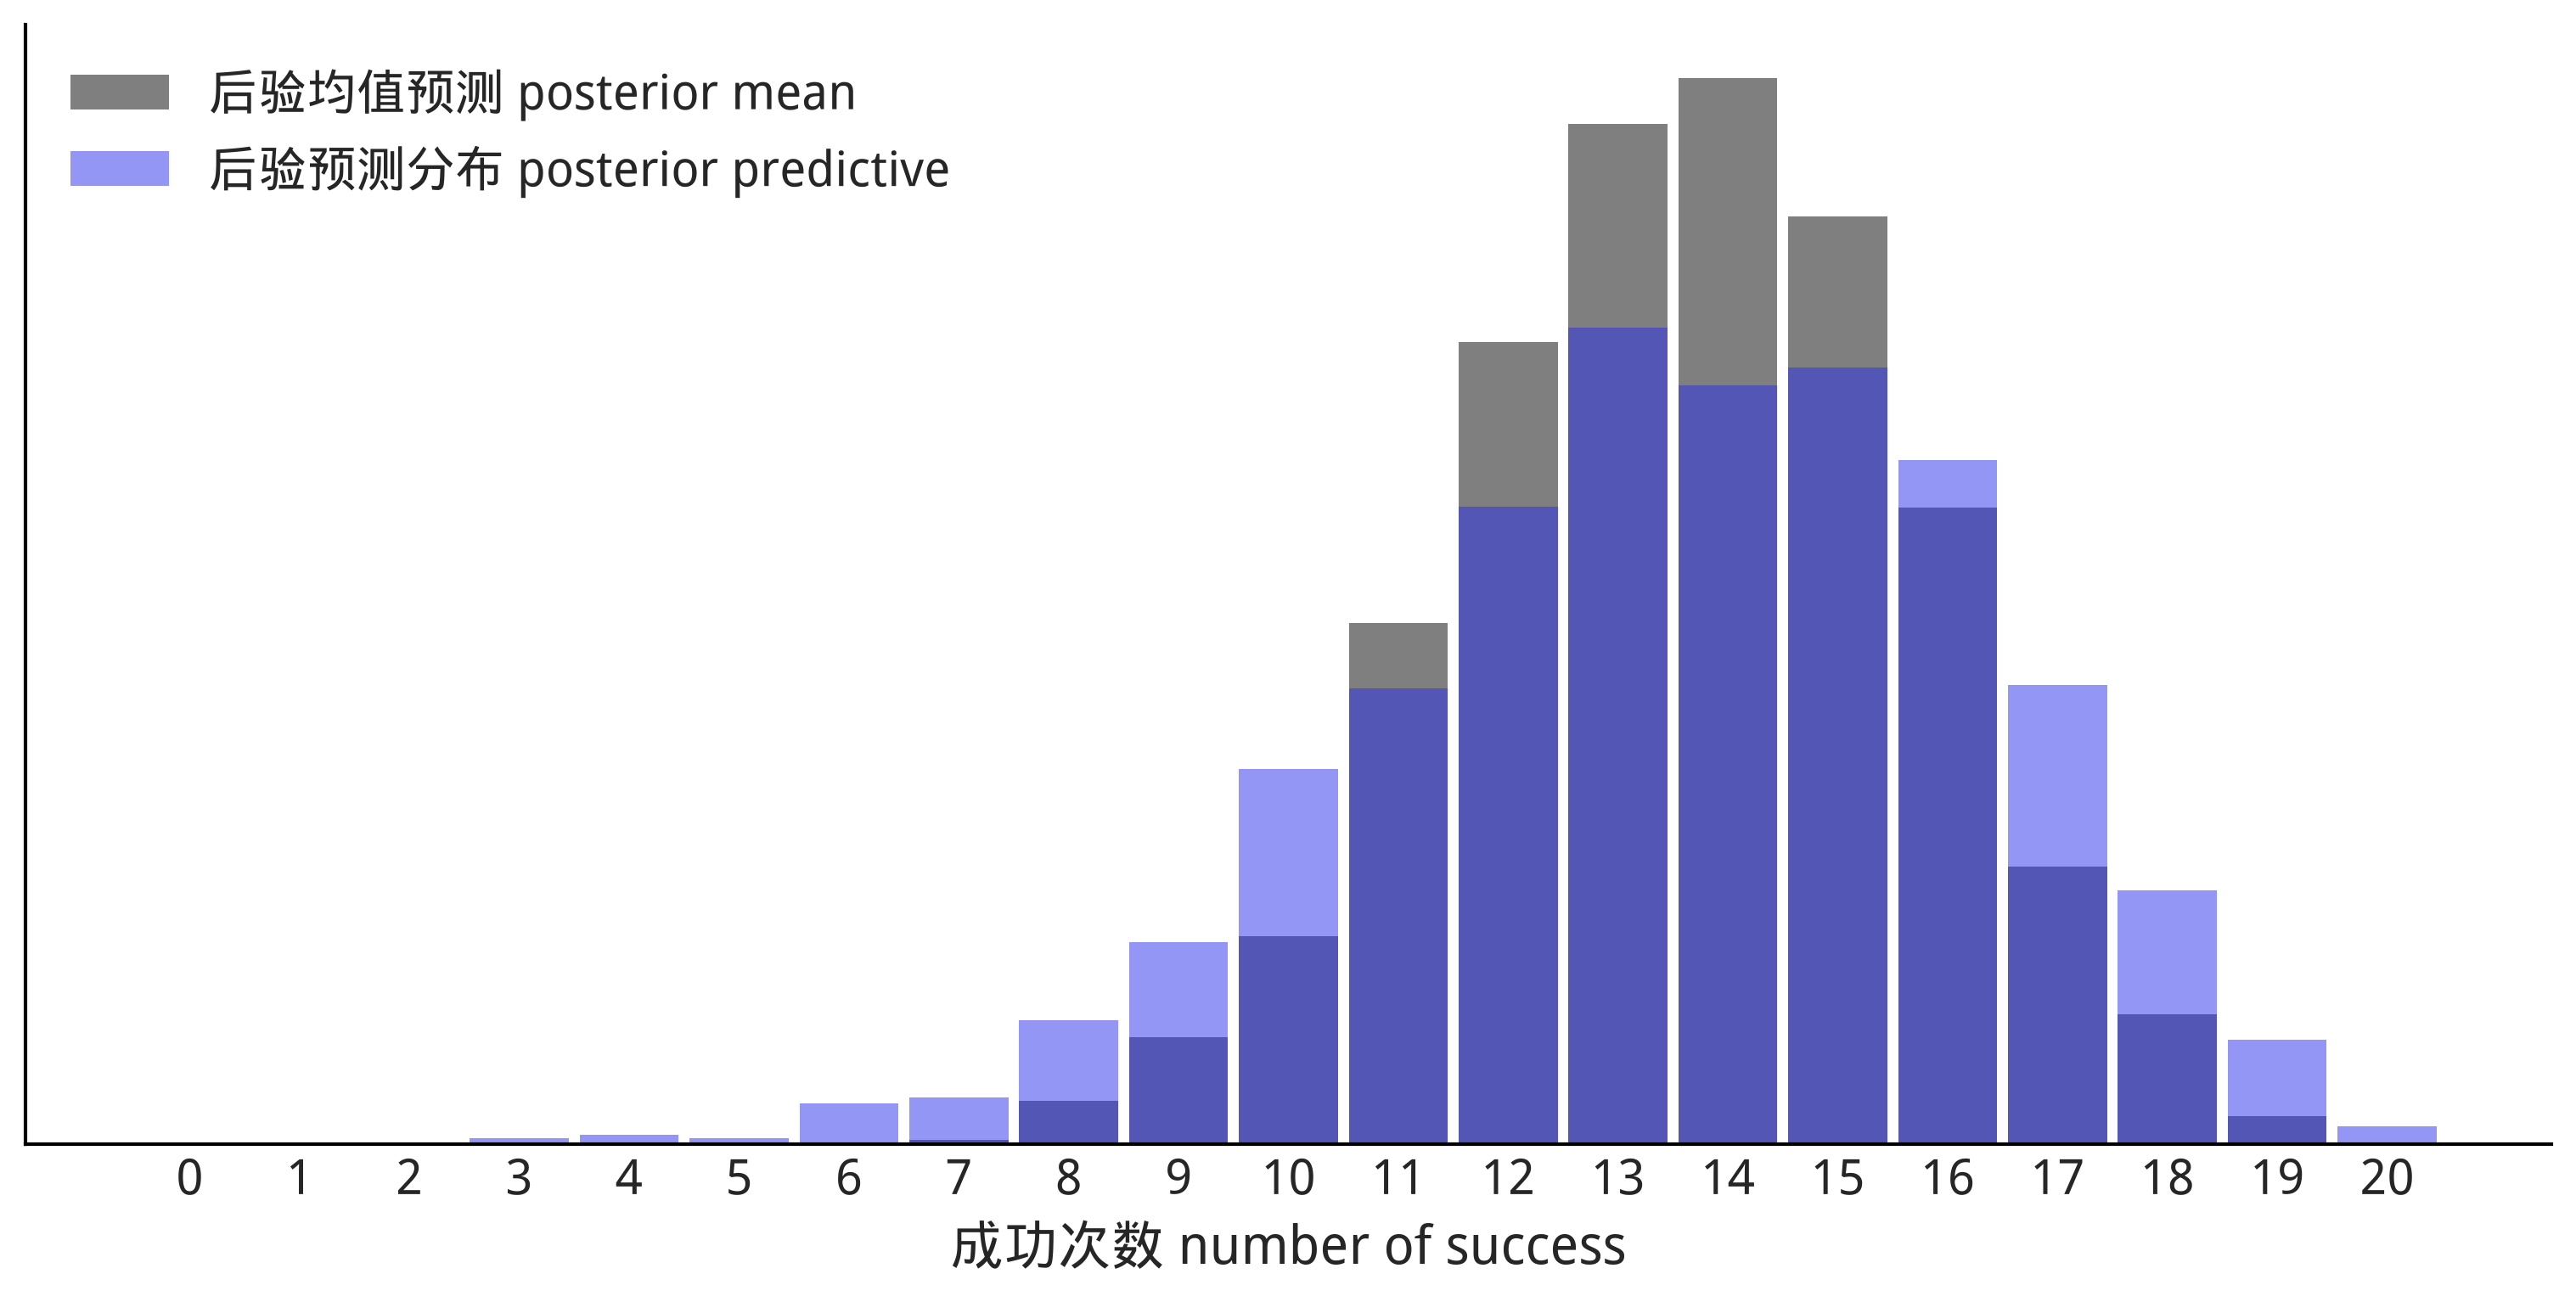

In [15]:
predictions = (stats.binom(n=1, p=idata.posterior["θ"].mean()).rvs((4000, len(Y))),
               pred_dists[1])

for d, c, l in zip(predictions, ("C0", "C4"), ("后验均值预测 posterior mean", "后验预测分布 posterior predictive")):
    ax = az.plot_dist(d.sum(-1),
                      label=l,
                      figsize=(10, 5),
                      hist_kwargs={"alpha": 0.5, "color": c, "bins": range(0, 22)})
    ax.set_yticks([])
    ax.set_xlabel("成功次数 number of success")
plt.savefig("img/chp01/predictions_distributions.png")



## 量化先验信息的几种思路

选择先验分布,常常被认为既是一种负担,也是一种恩赐。我们更愿意说,这是一种**必要性**:
如果你不去选择自己的先验,那么就会有别人替你做这个选择。让别人替你决定并不总是坏事——很
多非贝叶斯方法,只要用在正确的语境下、并了解其局限性,同样可以非常有用、非常高效。但我们
坚信,了解模型假设、并有能力调整这些假设,对实践者是有好处的。先验,只是这些假设中的一种。

我们也理解,先验的确定(prior elicitation)对很多实践者——尤其是(但不限于)刚入门的
新手——可能是困惑、焦虑乃至沮丧的来源。"某个问题最好的先验到底是什么?"是一个常见且完全
合理的问题,但很难给出一个令人满意的直接答案,因为压根不存在这样一个"最好的先验"。最多
只能说,在迭代式的建模工作流中,有一些好用的默认选项可以作为起点。

本节我们讨论几种选择先验分布的一般思路。这个讨论大致遵循一条"信息量递增的梯度":从完全
不包含任何信息的"白板"先验,到把尽可能多的信息塞进先验里的"高度信息化"先验。和本章其他
小节一样,这里的讨论偏理论;后续章节我们会讨论在更实际的场景下如何选择先验。

### 共轭先验

如果一个先验与某个似然搭配后,得到的后验和先验属于同一个分布族,我们就说这个先验相对该
似然是**共轭的(conjugate)**。例如,如果似然是泊松分布、先验是伽马分布,那么后验也会是
伽马分布 [^13]。

从纯数学的角度看,**共轭先验**是最方便的选择,因为它允许我们"纸笔推导"出后验分布的解析
解,不需要复杂的计算 [^14]。但从现代计算的角度看,共轭先验通常并不比其他选择更好——主要
原因是,现代计算方法几乎可以对任意先验做推断,而不只是局限于那些数学上"恰好方便"的先验。
不过,共轭先验在学习贝叶斯推断时依然很有用,在某些需要解析表达式的场合也有用武之地。因此
我们用 Beta-Binomial 模型来简单讨论一下解析先验。

顾名思义,二项分布的共轭先验是 Beta 分布:

$$
p(\theta \mid Y) \propto \overbrace{\frac{N!}{y!(N-y)!} \theta^y (1 - \theta)^{N-y}}^{\text{二项似然}} \: \overbrace{\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}\, \theta^{\alpha-1}(1-\theta)^{\beta-1}}^{\text{Beta 先验}}
$$

因为所有不依赖 $\theta$ 的项都是常数,可以丢掉,于是得到:

$$
p(\theta \mid Y) \propto \overbrace{\theta^y (1 - \theta)^{N-y}}^{\text{二项似然}} \: \overbrace{ \theta^{\alpha-1}(1-\theta)^{\beta-1}}^{\text{Beta 先验}}
$$

重新整理:

$$
p(\theta \mid Y) \propto \theta^{\alpha-1+y}(1-\theta)^{\beta-1+N-y}
$$

如果我们想让后验成为一个合法的概率密度函数,就需要添加一个归一化常数,使得该密度函数
积分为 1。注意到上式看起来正好是 Beta 分布的核(kernel),因此只需要补上 Beta 分布的
归一化常数,就能得出结论:Beta-Binomial 模型的后验分布是:

$$
p(\theta \mid Y) \propto \frac{\Gamma(\alpha_{post}+\beta_{post})}{\Gamma(\alpha_{post})\Gamma(\beta_{post})} \theta^{\alpha_{post}-1}(1-\theta)^{\beta_{post}-1} = \text{Beta}(\alpha_{post}, \beta_{post})
$$

其中 $\alpha_{post} = \alpha+y$,$\beta_{post} = \beta+N-y$。

因为 Beta-Binomial 模型的后验也是 Beta 分布,我们可以把某次分析得到的 Beta 后验,直接
当作下一次分析的先验来用。这意味着,不管我们是一次一个数据点地更新先验,还是一口气用
整个数据集来更新,最终得到的结果都是一样的。举例来说,下图前几个子图展示了不同先验在
0、1、2、3 次试验下如何被逐步更新。不管我们是按这个顺序一步步更新,还是直接从 0 次试验
"跳"到 3 次试验(或者任意 $n$ 次试验),结果都是相同的。

从下图中还能看到很多有趣的现象。比如随着试验次数增加,后验的宽度越来越窄,也就是说不
确定性越来越小。第 3 和第 5 个子图分别展示了"2 次试验 1 次成功"和"12 次试验 6 次成功"
这两种情形的结果——在这两种情形下,样本比例估计量 $\hat \theta = \frac{y}{n}$(图中黑点)
都是 0.5(后验众数也是 0.5),但第 5 个子图里后验的宽度明显更窄,这反映出观测数量更多、
不确定性也就更低。最后我们还能看到,随着观测数量增加,不同的先验最终都会收敛到同一个
后验分布。在数据量趋于无穷的极限情况下,不论用什么先验,后验的全部密度都会集中在
$\hat \theta = \frac{y}{n}$ 处。


/tmp/ipykernel_1646367/2688038698.py:19: RuntimeWarning: invalid value encountered in divide
  axes[idx].plot(np.divide(y, N), 0, color='k', marker='o', ms=12)


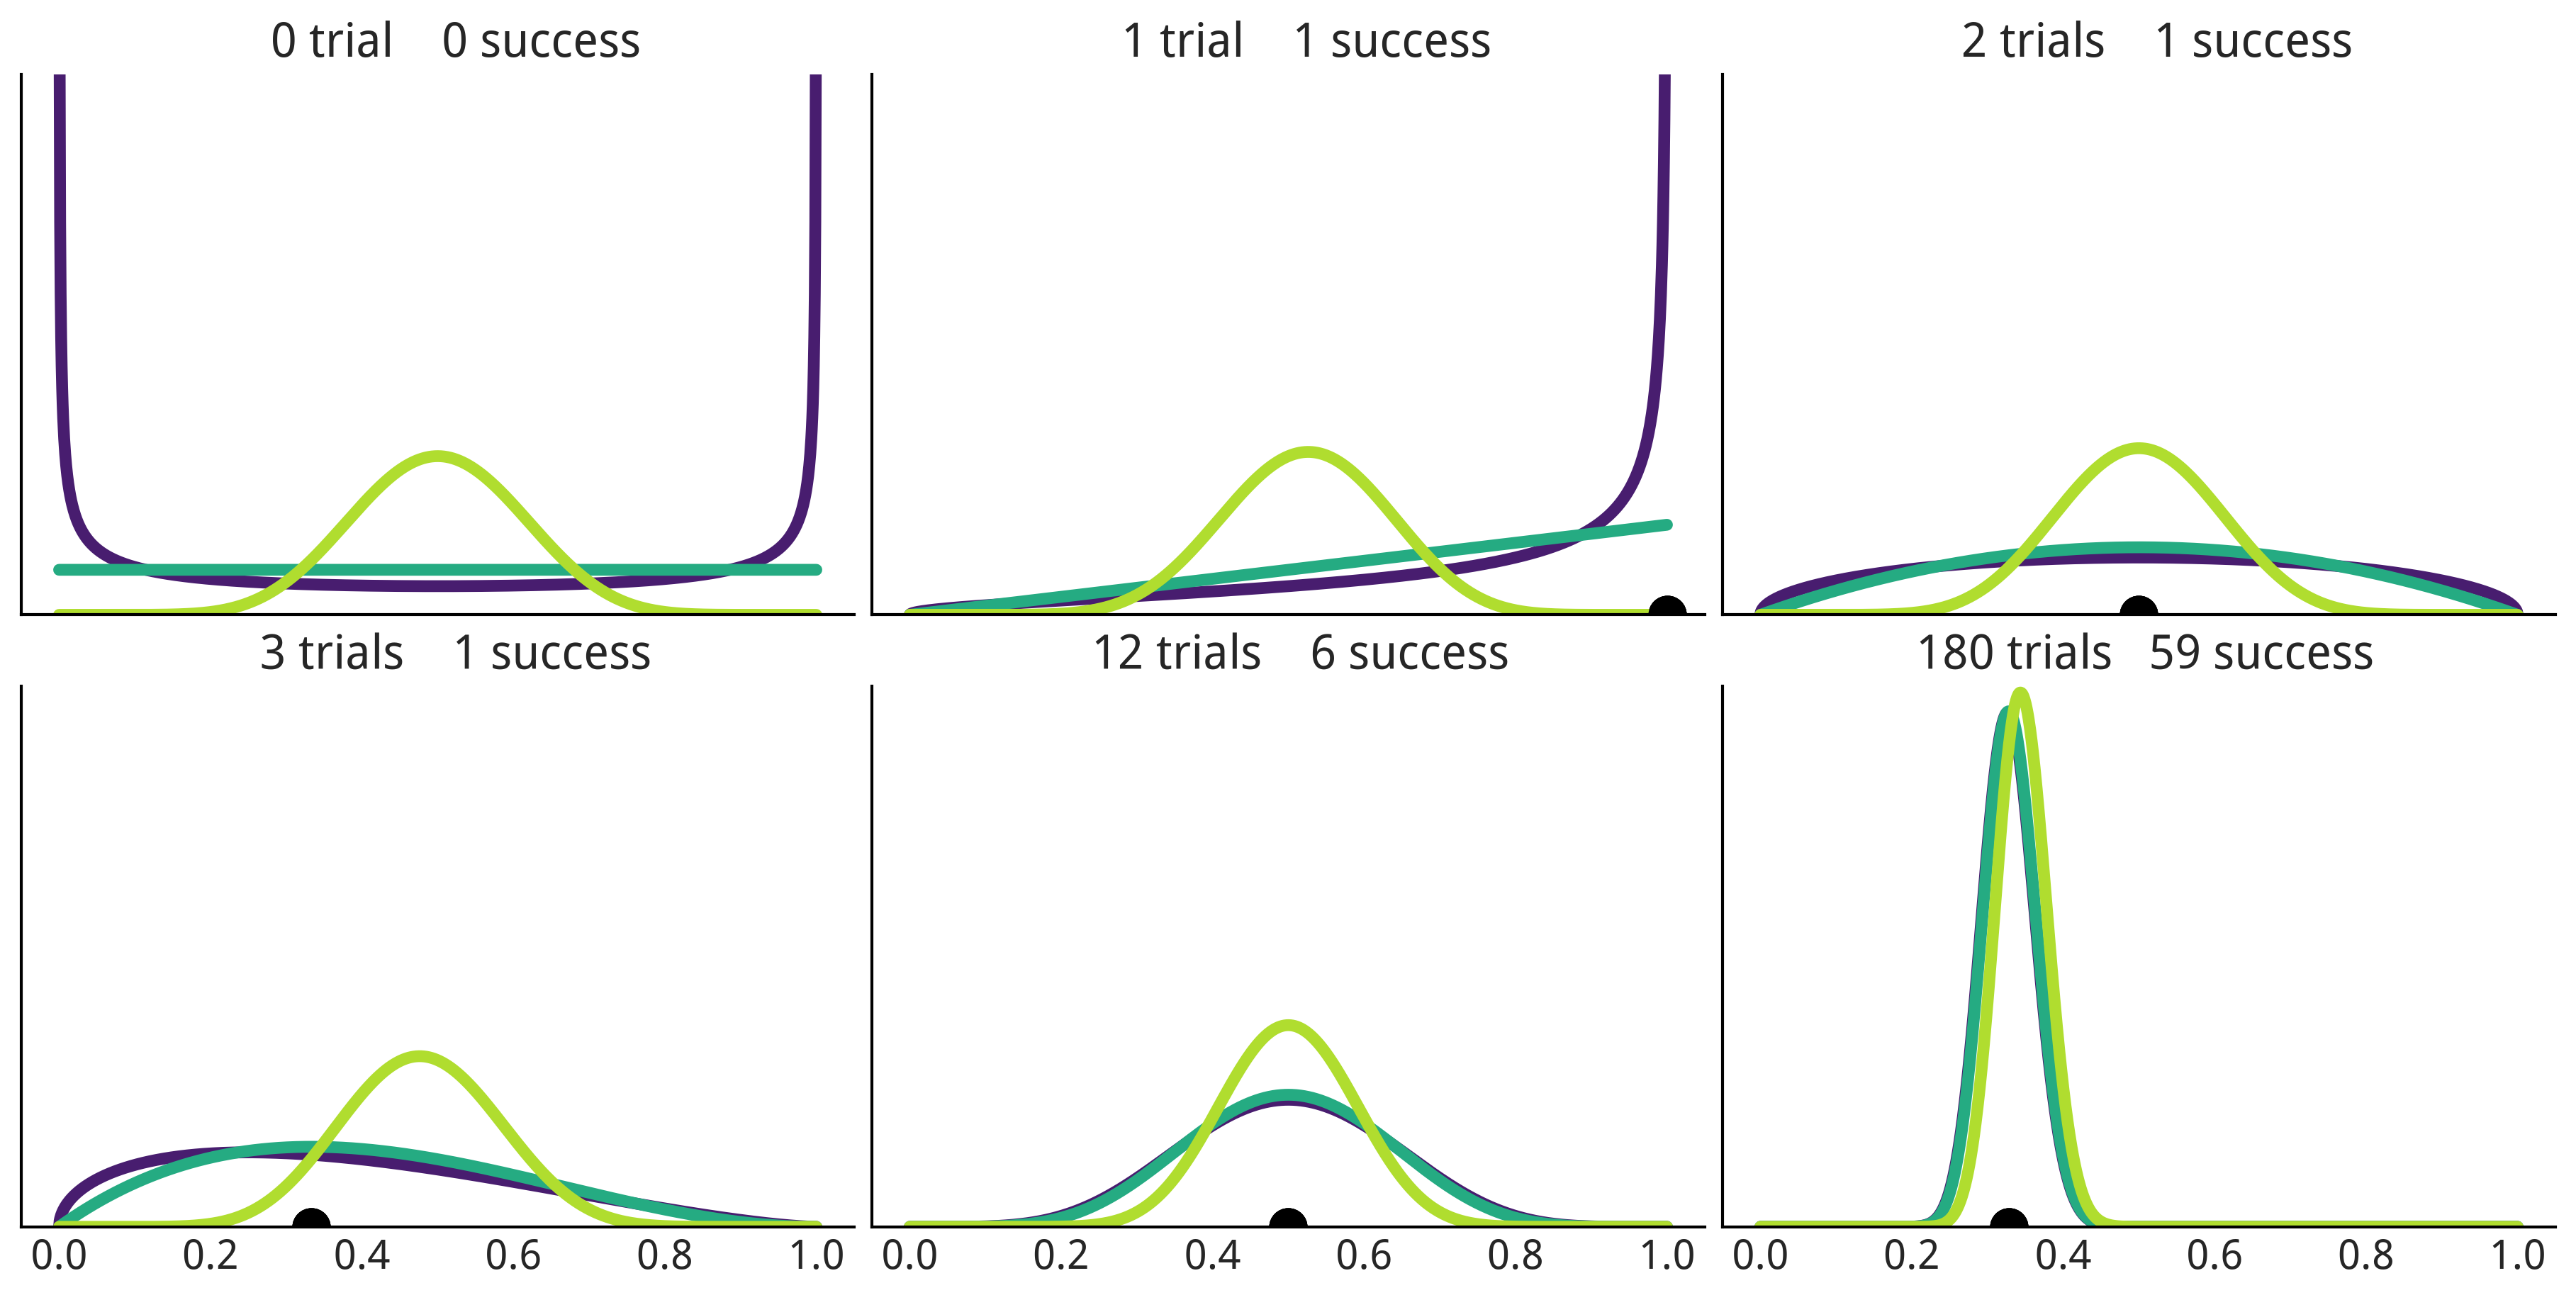

In [16]:
_, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True, sharex=True,
                     constrained_layout=True)
axes = np.ravel(axes)

n_trials = [0, 1, 2, 3, 12, 180]
success = [0, 1, 1, 1, 6, 59]
data = zip(n_trials, success)

beta_params = [(0.5, 0.5), (1, 1), (10, 10)]
θ = np.linspace(0, 1, 1500)
for idx, (N, y) in enumerate(data):
    s_n = ('s' if (N > 1) else '')
    for jdx, (a_prior, b_prior) in enumerate(beta_params):
        p_theta_given_y = stats.beta.pdf(θ, a_prior + y, b_prior + N - y)

        axes[idx].plot(θ, p_theta_given_y, lw=4, color=viridish[jdx])
        axes[idx].set_yticks([])
        axes[idx].set_ylim(0, 12)
        axes[idx].plot(np.divide(y, N), 0, color='k', marker='o', ms=12)
        axes[idx].set_title(f'{N:4d} trial{s_n} {y:4d} success')

plt.savefig('img/chp01/beta_binomial_update.png')



Beta 分布的均值是 $\frac{\alpha}{\alpha + \beta}$,因此先验均值是:

$$
\mathbb{E}[\theta]  = \frac{\alpha}{\alpha + \beta}
$$

后验均值是:

$$
\mathbb{E}[\theta \mid Y]  = \frac{\alpha + y}{\alpha + \beta + n}
$$

可以看到,如果 $n$ 相对 $\alpha$、$\beta$ 而言比较小,后验均值会更靠近先验均值——也就是
说,先验对结果的贡献更大。反过来,如果数据量相对更大,后验均值就会更靠近样本比例估计量
$\hat \theta = \frac{y}{n}$;事实上在 $n \rightarrow \infty$ 的极限下,不管 $\alpha$、
$\beta$ 取什么值,后验均值都会精确地等于样本比例。

Beta-Binomial 模型的后验众数是:

$$
\operatorname*{argmax}_{\theta}{[\theta \mid Y]}  = \frac{\alpha + y - 1}{\alpha + \beta + n - 2}
$$

可以看到,当先验是 $\text{Beta}(\alpha\!=\!1, \beta\!=\!1)$(即均匀分布)时,后验众数在
数值上正好等于样本比例估计量 $\hat \theta = \frac{y}{n}$。后验众数常被称为**最大后验估计
(maximum a posteriori, MAP)**。这一结果并非 Beta-Binomial 模型独有:事实上,很多非贝叶斯
方法的结果,都可以理解为在某些特定先验下的贝叶斯 MAP 估计 [^15]。

对比后验均值公式与样本比例 $\frac{y}{n}$:贝叶斯估计量相当于把 $\alpha$ 加到了成功次数
上,把 $\alpha + \beta$ 加到了试验总数上,这意味着 $\beta$ 相当于"失败次数"。从这个角度,
我们可以把先验的参数理解为**伪计数(pseudo counts)**,或者说是"先验数据"。先验
$\text{Beta}(1, 1)$ 就相当于已经做过两次试验,一次成功一次失败。从概念上讲,Beta 分布
的形状由参数 $\alpha$、$\beta$ 控制,观测数据会更新先验,让 Beta 分布的形状更靠近、也更
窄地集中在大多数观测值附近。当 $\alpha < 1$ 和/或 $\beta < 1$ 时,先验的这种解释会变得有
点怪——字面意义上讲,先验 $\text{Beta}(0.5, 0.5)$ 对应着"1 次试验,半次成功半次失败",
或者"1 次试验但结果未定"。有点诡异!

### 客观先验

在没有先验信息的情况下,遵循**无差别原则(principle of indifference)**——也叫**理由
不足原则**——听起来是合理的。这个原则基本是说:如果你对某个问题一无所知,那你就没有理由
相信某个结果比另一个结果更可能发生。在贝叶斯统计的语境下,这个原则催生了**客观先验
(objective priors)** 的研究与使用。这类先验是以系统化的方式生成的,对给定分析的影响
尽可能小。倾向于"苦行僧式"统计的人偏爱客观先验,因为这类先验消除了先验确定过程中的
**主观性**。当然,这并不能消除其他来源的主观性,比如似然的选择、数据采集过程、要建模或
研究的问题本身的选择等等,不一而足。

获得客观先验的一种方法叫做 **Jeffreys 先验(JP)**。这类先验常被称为"无信息的"
(non-informative),即便严格来说先验总是在某种意义上携带信息。更准确的描述是:JP 具有
在**重参数化(reparametrization)**——也就是用不同但数学上等价的方式改写表达式——下
保持不变的性质。我们用一个例子来说明这具体是什么意思。假设 Alice 有一个未知参数为
$\theta$ 的二项似然,她选定一个先验并计算出后验。Alice 的朋友 Bob 对同一个问题感兴趣,
但他关心的不是成功次数 $\theta$,而是成功的**赔率(odds)** $\kappa$,即
$\kappa = \frac{\theta}{1-\theta}$。Bob 有两种选择:要么用 Alice 关于 $\theta$ 的后验
来推算出 $\kappa$ [^16],要么自己为 $\kappa$ 选一个先验来算后验。JP 保证的是:如果 Alice
和 Bob 都用 JP,那么不管 Bob 选择上面哪种做法,最终得到的结果都是一致的。在这个意义上,
我们说结果对所选的参数化方式是**不变的(invariant)**。由此可以得出一个推论:除非我们
使用 JP,否则无法保证同一个模型的两种(或更多种)参数化方式,最终会得到彼此一致的后验。

对一维情形,$\theta$ 的 JP 是:

$$
p(\theta) \propto \sqrt{I(\theta)}
$$

其中 $I(\theta)$ 是期望 Fisher 信息量:

$$
I(\theta) = - \mathbb{E_{Y}}\left[\frac{d^2}{d\theta^2} \log p(Y \mid \theta)\right]
$$

一旦实践者确定了似然函数 $p(Y \mid \theta)$,JP 就自动确定了,不再需要围绕先验选择进行
讨论——直到会场后排那位爱较真的听众,又开始质疑你选用 JP 这件事本身。

跳过详细推导,Alice 的 JP 是:

$$
p(\theta) \propto \theta^{-0.5} (1-\theta)^{-0.5}
$$

这正是 $\text{Beta}(0.5, 0.5)$ 分布的核,是一个"U 形"分布,如下图左上子图所示。

Bob 的 JP 是:

$$
p(\kappa) \propto \kappa^{-0.5} (1 + \kappa)^{-1}
$$

这是定义在 $[0, \infty)$ 区间上的"半 U 形"分布(见下图右上子图)。听起来有点奇怪,但其实
不然——这正是 Beta 分布的"近亲"—— Beta-prime 分布,参数为 $\alpha=\beta=0.5$ 时的核。


/tmp/ipykernel_1646367/588671948.py:2: RuntimeWarning: divide by zero encountered in divide
  κ = (θ / (1-θ))
/tmp/ipykernel_1646367/588671948.py:10: RuntimeWarning: divide by zero encountered in power
  axes[0, 0].plot(θ, θ**(-0.5) * (1-θ)**(-0.5))
/tmp/ipykernel_1646367/588671948.py:15: RuntimeWarning: divide by zero encountered in power
  axes[0, 1].plot(κ, κ**(-0.5) * (1 + κ)**(-1))
/tmp/ipykernel_1646367/588671948.py:17: RuntimeWarning: invalid value encountered in multiply
  axes[1, 1].plot(κ, κ**(y-0.5) * (1 + κ)**(-n-1))


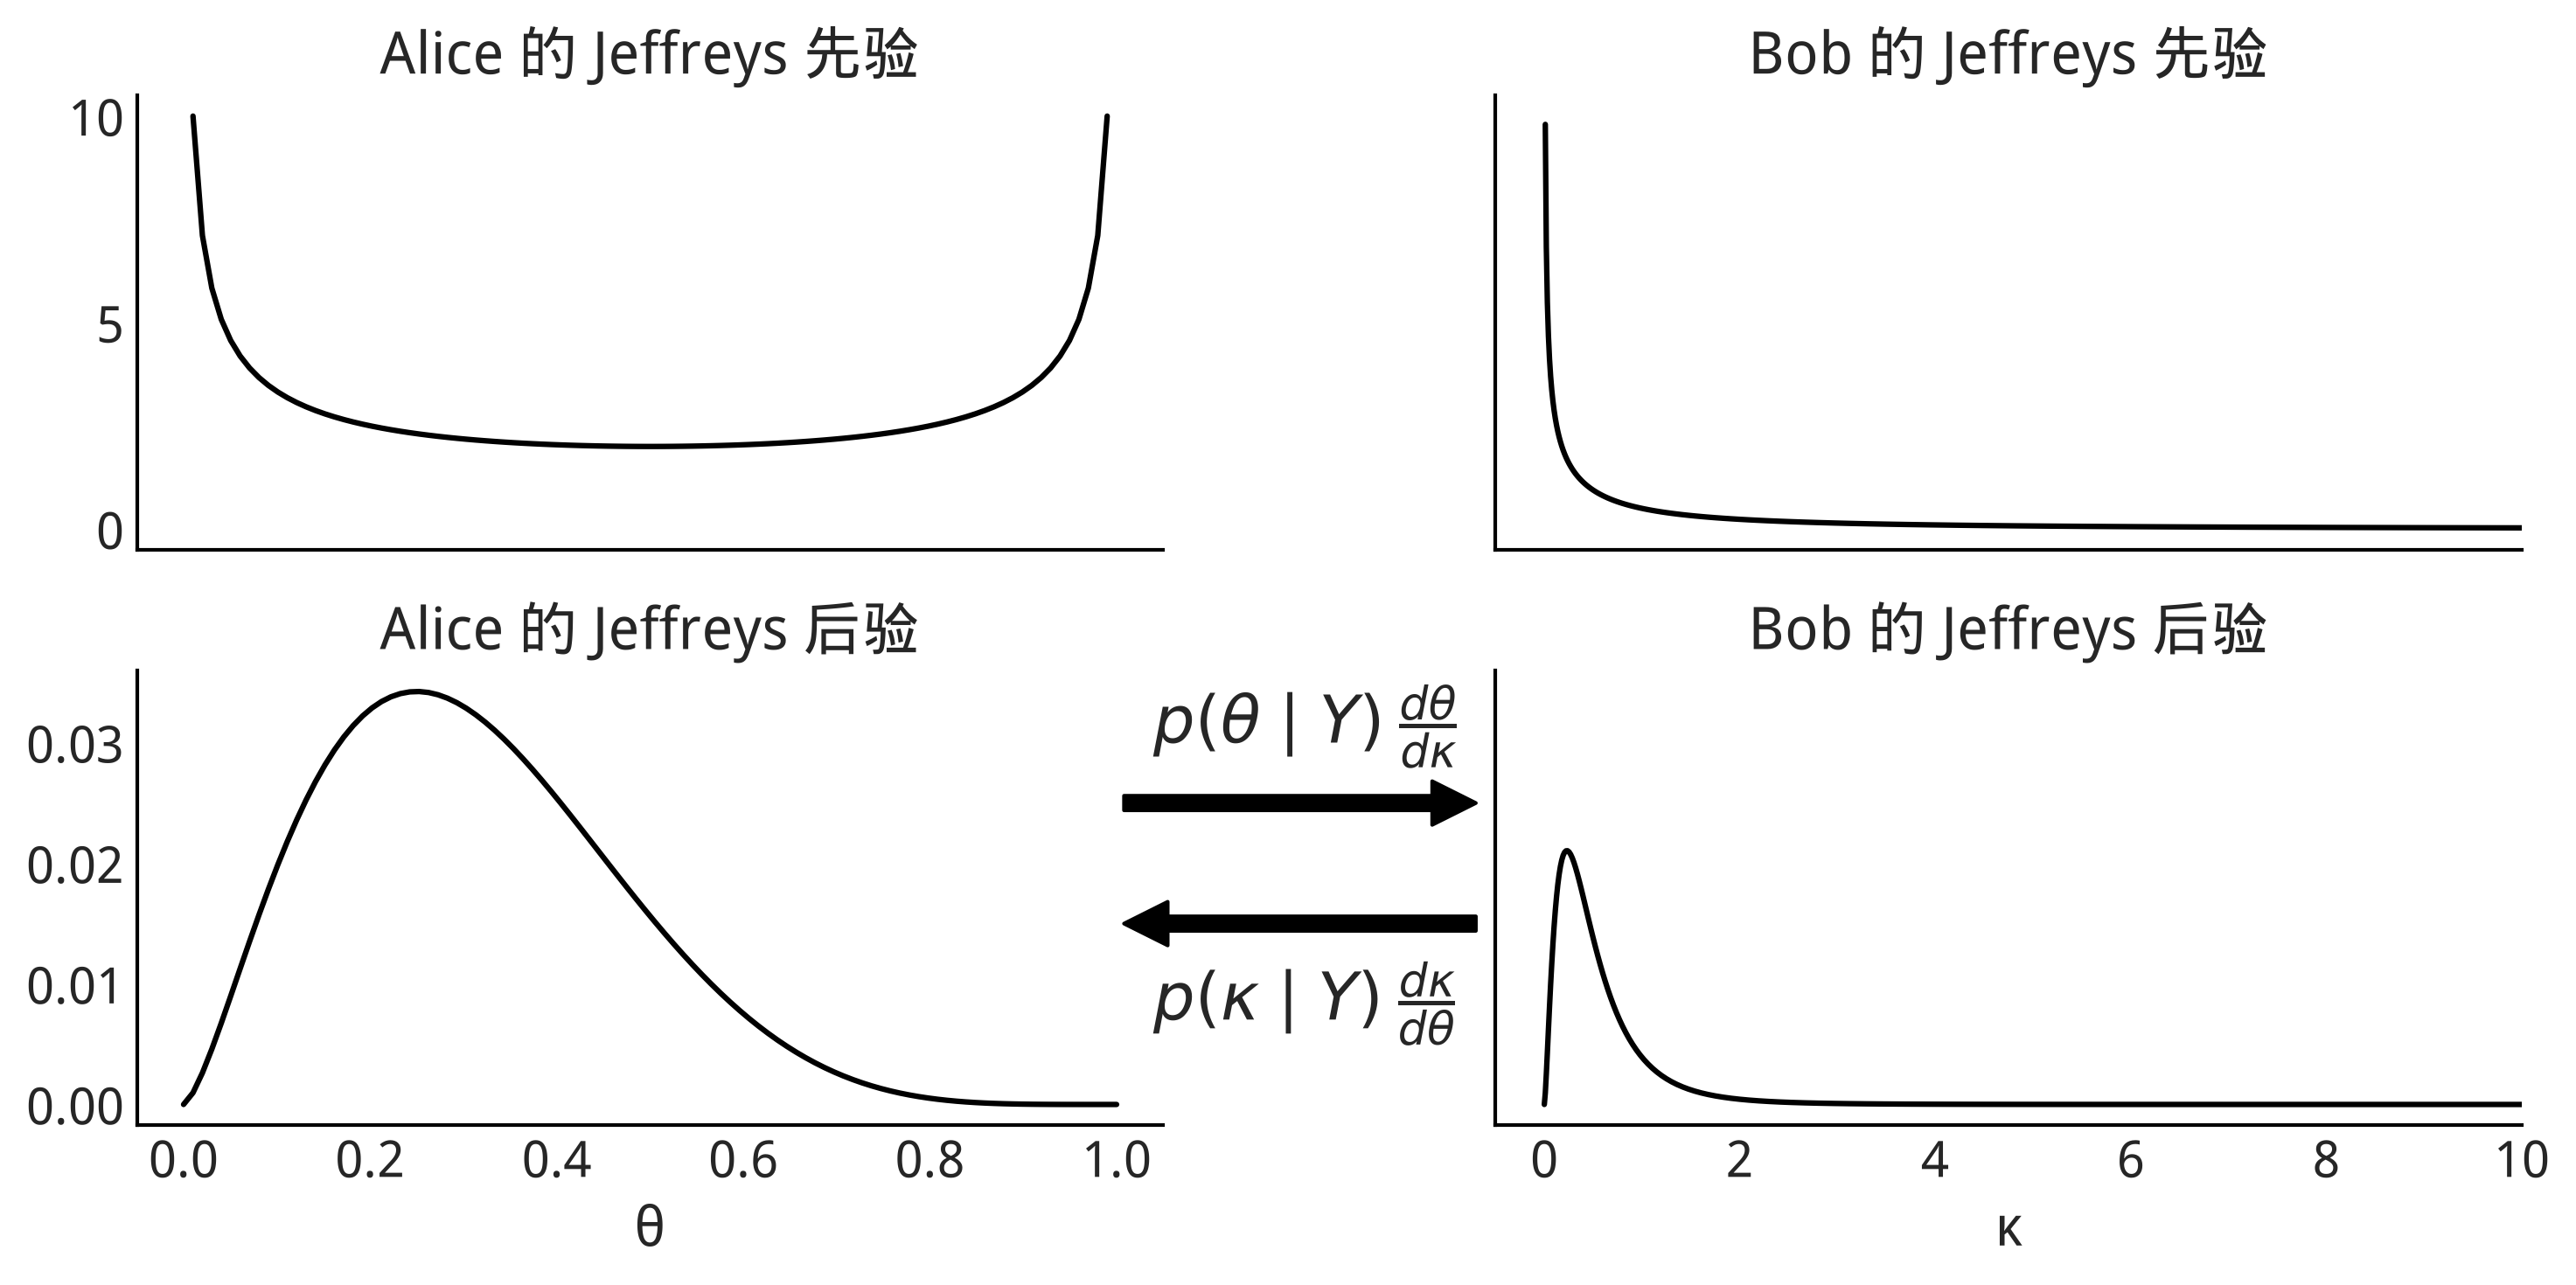

In [17]:
θ = np.linspace(0, 1, 100)
κ = (θ / (1-θ))
y = 2
n = 7

_, axes = plt.subplots(2, 2, figsize=(10, 5),
                     sharex='col', sharey='row', constrained_layout=False)

axes[0, 0].set_title("Alice 的 Jeffreys 先验")
axes[0, 0].plot(θ, θ**(-0.5) * (1-θ)**(-0.5))
axes[1, 0].set_title("Alice 的 Jeffreys 后验")
axes[1, 0].plot(θ, θ**(y-0.5) * (1-θ)**(n-y-0.5))
axes[1, 0].set_xlabel("θ")
axes[0, 1].set_title("Bob 的 Jeffreys 先验")
axes[0, 1].plot(κ, κ**(-0.5) * (1 + κ)**(-1))
axes[1, 1].set_title("Bob 的 Jeffreys 后验")
axes[1, 1].plot(κ, κ**(y-0.5) * (1 + κ)**(-n-1))
axes[1, 1].set_xlim(-0.5, 10)
axes[1, 1].set_xlabel("κ")
axes[1, 1].text(-4.0, 0.030, size=18, s=r'$p(\theta \mid Y) \, \frac{d\theta}{d\kappa}$')
axes[1, 1].annotate("", xy=(-0.5, 0.025), xytext=(-4.5, 0.025),
                  arrowprops=dict(facecolor='black', shrink=0.05))
axes[1, 1].text(-4.0, 0.007, size=18, s= r'$p(\kappa \mid Y) \, \frac{d\kappa}{d\theta}$')
axes[1, 1].annotate("", xy=(-4.5, 0.015), xytext=(-0.5, 0.015),
                  arrowprops=dict(facecolor='black', shrink=0.05),
                  annotation_clip=False)

plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.savefig("img/chp01/Jeffrey_priors.png")



注意,由于上式中的期望是对 $Y \mid \theta$ 求的,也就是对**样本空间**求期望。这意味着,
要得到一个 JP,我们需要对所有可能的实验结果取平均。这违反了似然原理(likelihood
principle)[^17]——因为这样一来,关于 $\theta$ 的推断不仅依赖于手头的数据,还依赖于一整
个尚未(或永远不会)被观测到的潜在数据集合。

JP 可以是一个非正常先验(improper prior),也就是说它并不积分为 1。例如,已知方差的高斯
分布的均值,其 JP 是整条实数轴上的均匀分布。只要我们能验证:非正常先验与似然结合后,依然
能得到一个"正常"(积分为 1)的后验分布,那么使用非正常先验就是没问题的。但也要注意,我们
无法从非正常先验中抽取随机样本(也就是说它们不是"可生成的"),这会使很多用于推理模型的
有用工具失效。

JP 并不是获得客观先验的唯一方式。另一条路径是,通过最大化先验和后验之间的期望
Kullback-Leibler 散度来得到先验,这类先验被称为 Bernardo 参考先验(reference priors)。
之所以说它们是"客观的",是因为这类先验恰恰是能让数据把**最大量**的信息带入后验的先验。
Bernardo 参考先验和 Jeffreys 先验并不一定给出相同的结果。此外,对于复杂模型,客观先验
有可能根本不存在,或者很难推导出来。

### 最大熵先验

另一种为先验选择提供依据的方式,是挑选**熵最大**的先验。如果我们对各种可能取值完全不做
区分,那么这样的先验就是在合理取值范围上的均匀分布 [^18]。但如果我们并非对所有取值都
完全无差别呢?比如我们可能知道参数被限制在 $[0, \infty)$ 区间内。这时候,我们能不能在
满足给定约束的同时,得到一个熵最大的先验?答案是可以,这正是**最大熵先验**背后的核心思想。
文献中通常把这称为 MaxEnt(最大熵原理的缩写)。

要得到一个最大熵先验,需要在一组约束条件下求解一个优化问题,数学上可以用拉格朗日乘子法
来完成。这里我们不做形式化证明,而是用几个代码示例来建立直观感受。

下图展示了通过熵最大化得到的 3 个分布。紫色的分布是在没有任何约束条件下得到的,我们会
欣喜地发现,它正好是均匀分布——这和前面关于熵的讨论是吻合的:如果我们对问题一无所知,
那么先验地讲,所有结果都应该是等可能的。第二个分布(青色)是在"已知分布均值"这一约束下
得到的(本例中均值为 1.5),在这个约束下我们得到了一个类似指数分布的形状。最后一个
黄绿色的分布,是在"已知取值 3 和 4 出现的概率合计为 0.8"这一约束下得到的。如果你看下面
的代码就会发现,所有这些分布都是在两个通用约束下计算出来的:概率只能取 $[0, 1]$ 区间内的
值,并且总概率必须为 1。因为这些是任何合法概率分布都必须满足的通用约束,我们可以把它们
看作是**内在的**甚至是**本体论意义上**的约束——正因如此,我们才说紫色分布是"无约束"下
得到的。


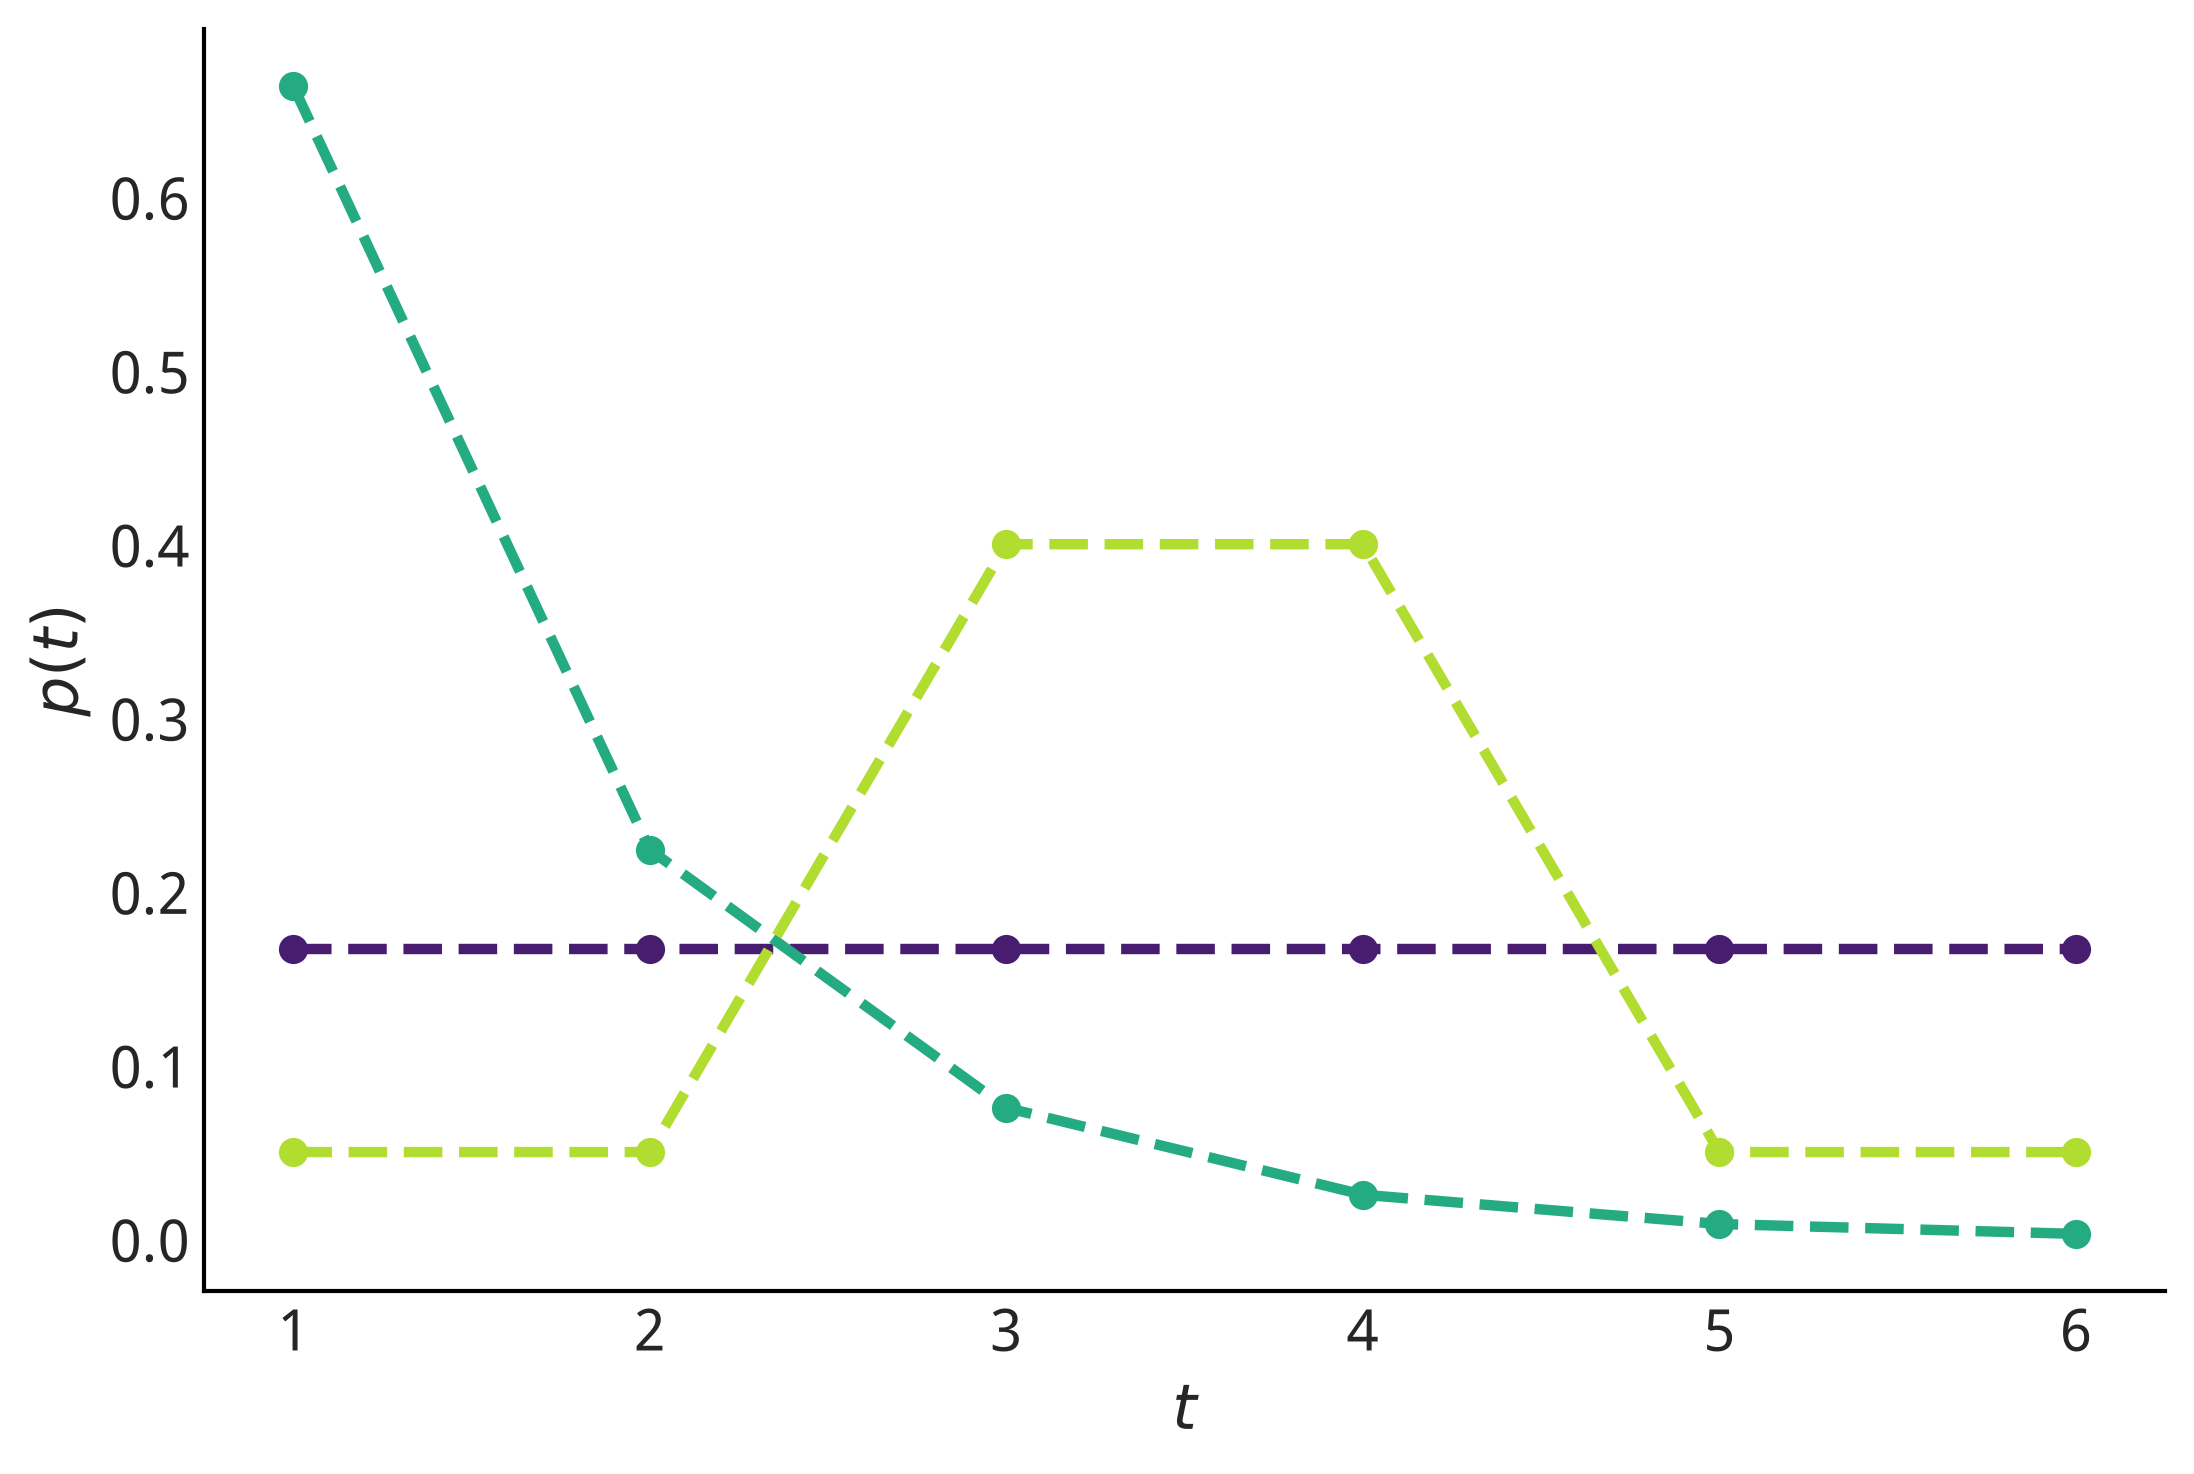

In [18]:
cons = [[{"type": "eq", "fun": lambda x: np.sum(x) - 1}],
        [{"type": "eq", "fun": lambda x: np.sum(x) - 1},
         {"type": "eq", "fun": lambda x: 1.5 - np.sum(x * np.arange(1, 7))}],
        [{"type": "eq", "fun": lambda x: np.sum(x) - 1},
         {"type": "eq", "fun": lambda x: np.sum(x[[2, 3]]) - 0.8}]]

max_ent = []
for i, c in enumerate(cons):
    val = minimize(lambda x: -entropy(x), x0=[1/6]*6, bounds=[(0., 1.)] * 6,
                   constraints=c)['x']
    max_ent.append(entropy(val))
    plt.plot(np.arange(1, 7), val, 'o--', color=viridish[i], lw=2.5)
plt.xlabel("$t$")
plt.ylabel("$p(t)$")

plt.savefig("img/chp01/max_entropy.png")



我们可以把最大熵原理理解为:在给定约束条件下,挑选"最平坦"的分布(推广到先验,就是最
平坦的先验分布)。上图中,均匀分布是最平坦的分布,但注意,一旦加上"数值 3 和 4 有 80%
概率出现"这个约束,绿色的分布同样是在该约束下最平坦的分布。注意 3 和 4 各自的概率都恰好
是 0.4——尽管理论上有无穷多种方式可以把 0.8 拆分给这两个数值,比如 0+0.8、0.7+0.1、
0.312+0.488 等等。类似地,数值 1、2、5、6 总共分到 0.2 的概率,且被均匀地分配(每个
0.05)。再看那条类似指数分布的曲线,它看起来一点也不"平坦",但同样地,别的选择只会更不
平坦、更集中——比如让 1 和 2 各占 50% 的概率(3 到 6 的概率归零),这样同样能满足期望值
为 1.5 的约束,但显然更不"平坦"。

为了从实验上验证这一点,我们可以随机生成大量满足同样约束条件的分布,计算它们各自的熵,
和上面通过优化得到的最大熵分布相比较:


In [19]:
ite = 100_000
entropies = np.zeros((3, ite))
for idx in range(ite):
    rnds = np.zeros(6)
    total = 0
    x_ = np.random.choice(np.arange(1, 7), size=6, replace=False)
    for i in x_[:-1]:
        rnd = np.random.uniform(0, 1-total)
        rnds[i-1] = rnd
        total = rnds.sum()
    rnds[-1] = 1 - rnds[:-1].sum()
    H = entropy(rnds)
    entropies[0, idx] = H
    if abs(1.5 - np.sum(rnds * x_)) < 0.01:
        entropies[1, idx] = H
    prob_34 = sum(rnds[np.argwhere((x_ == 3) | (x_ == 4)).ravel()])
    if abs(0.8 - prob_34) < 0.01:
        entropies[2, idx] = H



下图展示的正是这些随机生成的分布,在与上面 3 个分布完全相同的约束条件下计算出的熵的
分布情况。图中的虚线代表最大熵分布本身的熵。虽然这算不上一个严格证明,但这个小实验似乎
表明:不存在熵比我们算出的最大熵分布更高的分布——这和理论给出的结论完全一致。


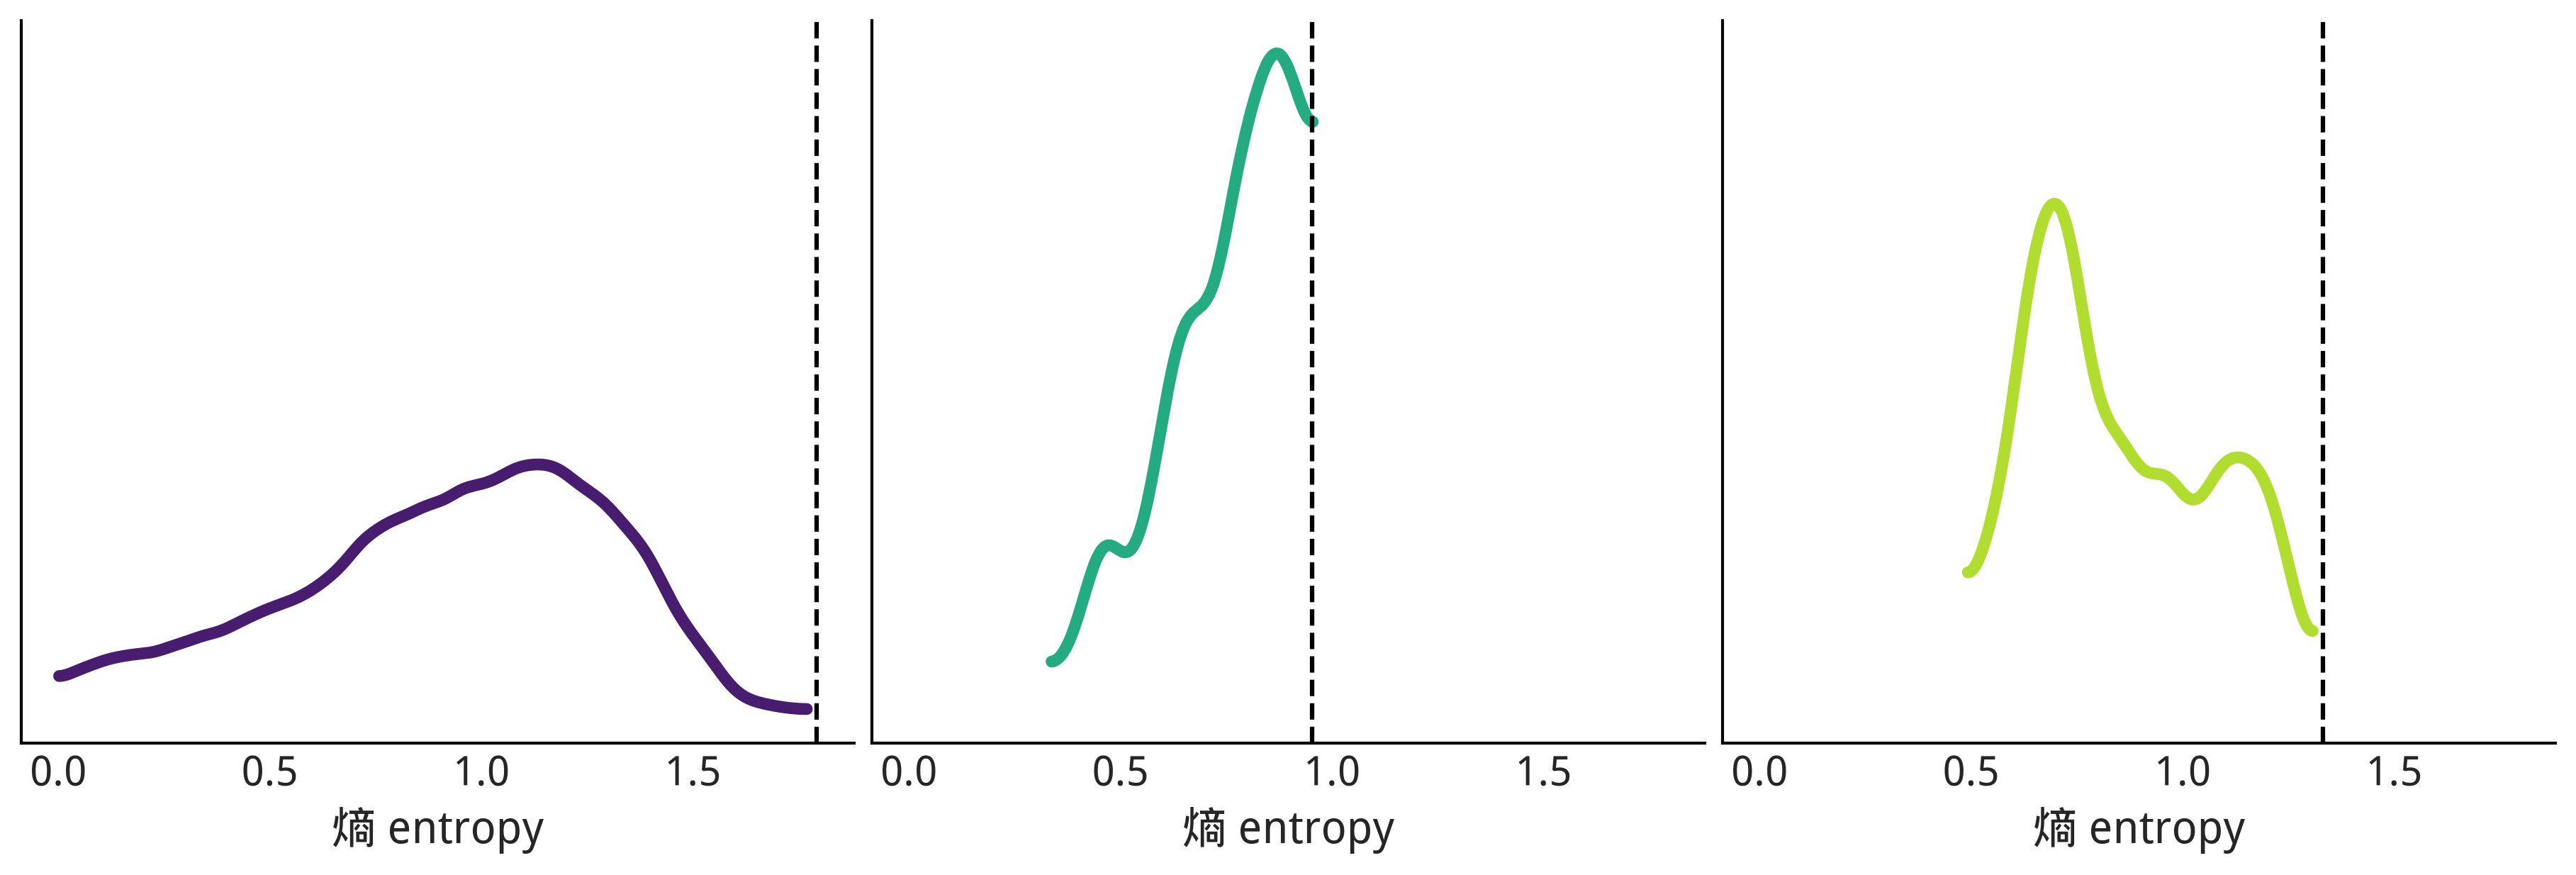

In [20]:
_, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)

for i in range(3):
    # 新版 matplotlib 不再允许同时传入 'lw' 与其全称别名 'linewidth'
    # (ArviZ 内部会补一个默认 linewidth),这里统一用全称避免冲突
    az.plot_kde(entropies[i][np.nonzero(entropies[i])], ax=ax[i], plot_kwargs={"color": viridish[i], "linewidth": 4})
    ax[i].axvline(max_ent[i], 0, 1, ls="--")
    ax[i].set_yticks([])
    ax[i].set_xlabel("熵 entropy")
plt.savefig("img/chp01/max_entropy_vs_random_dist.png")



在以下约束条件下,熵最大的分布分别是 [^19]:

- 无约束:均匀分布(离散或连续,取决于变量类型)
- 均值为正,支持集为 $[0, \infty)$:指数分布
- 到均值的绝对偏差已知,支持集为 $(-\infty, \infty)$:拉普拉斯分布(也叫双指数分布)
- 给定均值和方差,支持集为 $(-\infty, \infty)$:正态分布
- 给定均值和方差,支持集为 $[-\pi, \pi]$:冯·米塞斯分布(Von Mises)
- 只有两个无序结果、均值恒定:二项分布;如果事件很罕见,则是泊松分布(泊松分布可以看作
  是二项分布的一个特例)

值得一提的是,第 3 章介绍的很多广义线性模型,传统上正是根据模型的约束条件,基于最大熵
分布来定义的。和客观先验类似,最大熵先验也可能不存在,或者很难推导出来。

### 弱信息先验与正则化先验

前面几节我们用一般化的方法来生成模糊、无信息的先验,目的是不把*过多*信息带入分析。这些
生成先验的方法也提供了一种"某种程度上"自动化的先验生成方式。这两个特点听起来都很有吸引力,
对不少贝叶斯实践者和理论学者来说的确如此。

但在本书中,我们不会过多依赖这类先验。我们认为,先验的确定(和其他建模决策一样)应该
依赖于具体语境——也就是说,某个具体问题的细节,甚至某个科研领域特有的惯例,都应该能够
影响我们对先验的选择。虽然最大熵先验也可以纳入一部分这样的限制条件,但我们可以在"信息量
谱系"上再往"信息化"那一端靠近一点,这就是所谓的**弱信息先验(weakly informative
priors)**。

什么样的先验算是"弱信息"的,通常没有像 JP 或 MaxEnt 那样精确的数学定义。相反,它们更多
是**经验性的**、**由模型驱动的**——也就是说,是相关领域专业知识和模型本身共同作用的产物。
对很多问题来说,我们往往对参数可能的取值范围有一些信息,这些信息可能来自参数本身的物理
含义(比如我们知道身高必须是正数),也可能来自以前的实验或观测结果,让我们对参数的合理
取值范围有所了解。我们也可能有充分理由认为某个值应该接近零,或者高于某个预先设定的下界。
我们可以利用这些信息来"弱"地引导分析,同时保留足够的无知,避免*用力过猛*。

依然以 Beta-Binomial 模型为例,下图展示了 4 种备选先验:其中两个是前面提到的 JP 和最大熵
先验;一个可以称为弱信息先验,它偏好 $\theta=0.5$ 附近的取值,但对其他取值依然保持相对
宽泛、模糊的态度;最后一个是信息先验,紧紧围绕 $\theta=0.8$ [^20]。如果我们确实拥有来自
理论、以往实验、观测数据等方面的高质量信息,使用信息先验是完全合理的选择。因为信息先验
携带了大量信息,通常需要比其他先验更有力的论证支持。正如卡尔·萨根常说的那句话:
"非同寻常的主张需要非同寻常的证据"。需要记住的是,先验的信息量高低,取决于具体的模型
和语境:在某个语境下是无信息的先验,换一个语境可能就变成了高度信息化的先验。举例来说,
如果建模的是成年人身高的均值(单位:米),$\mathcal{N}(2,1)$ 这样的先验可以被认为是无
信息的;但如果拿来估计长颈鹿的身高,同样的先验就变成了高度信息化的先验——因为长颈鹿的
身高和人类的身高实际上相差很大。


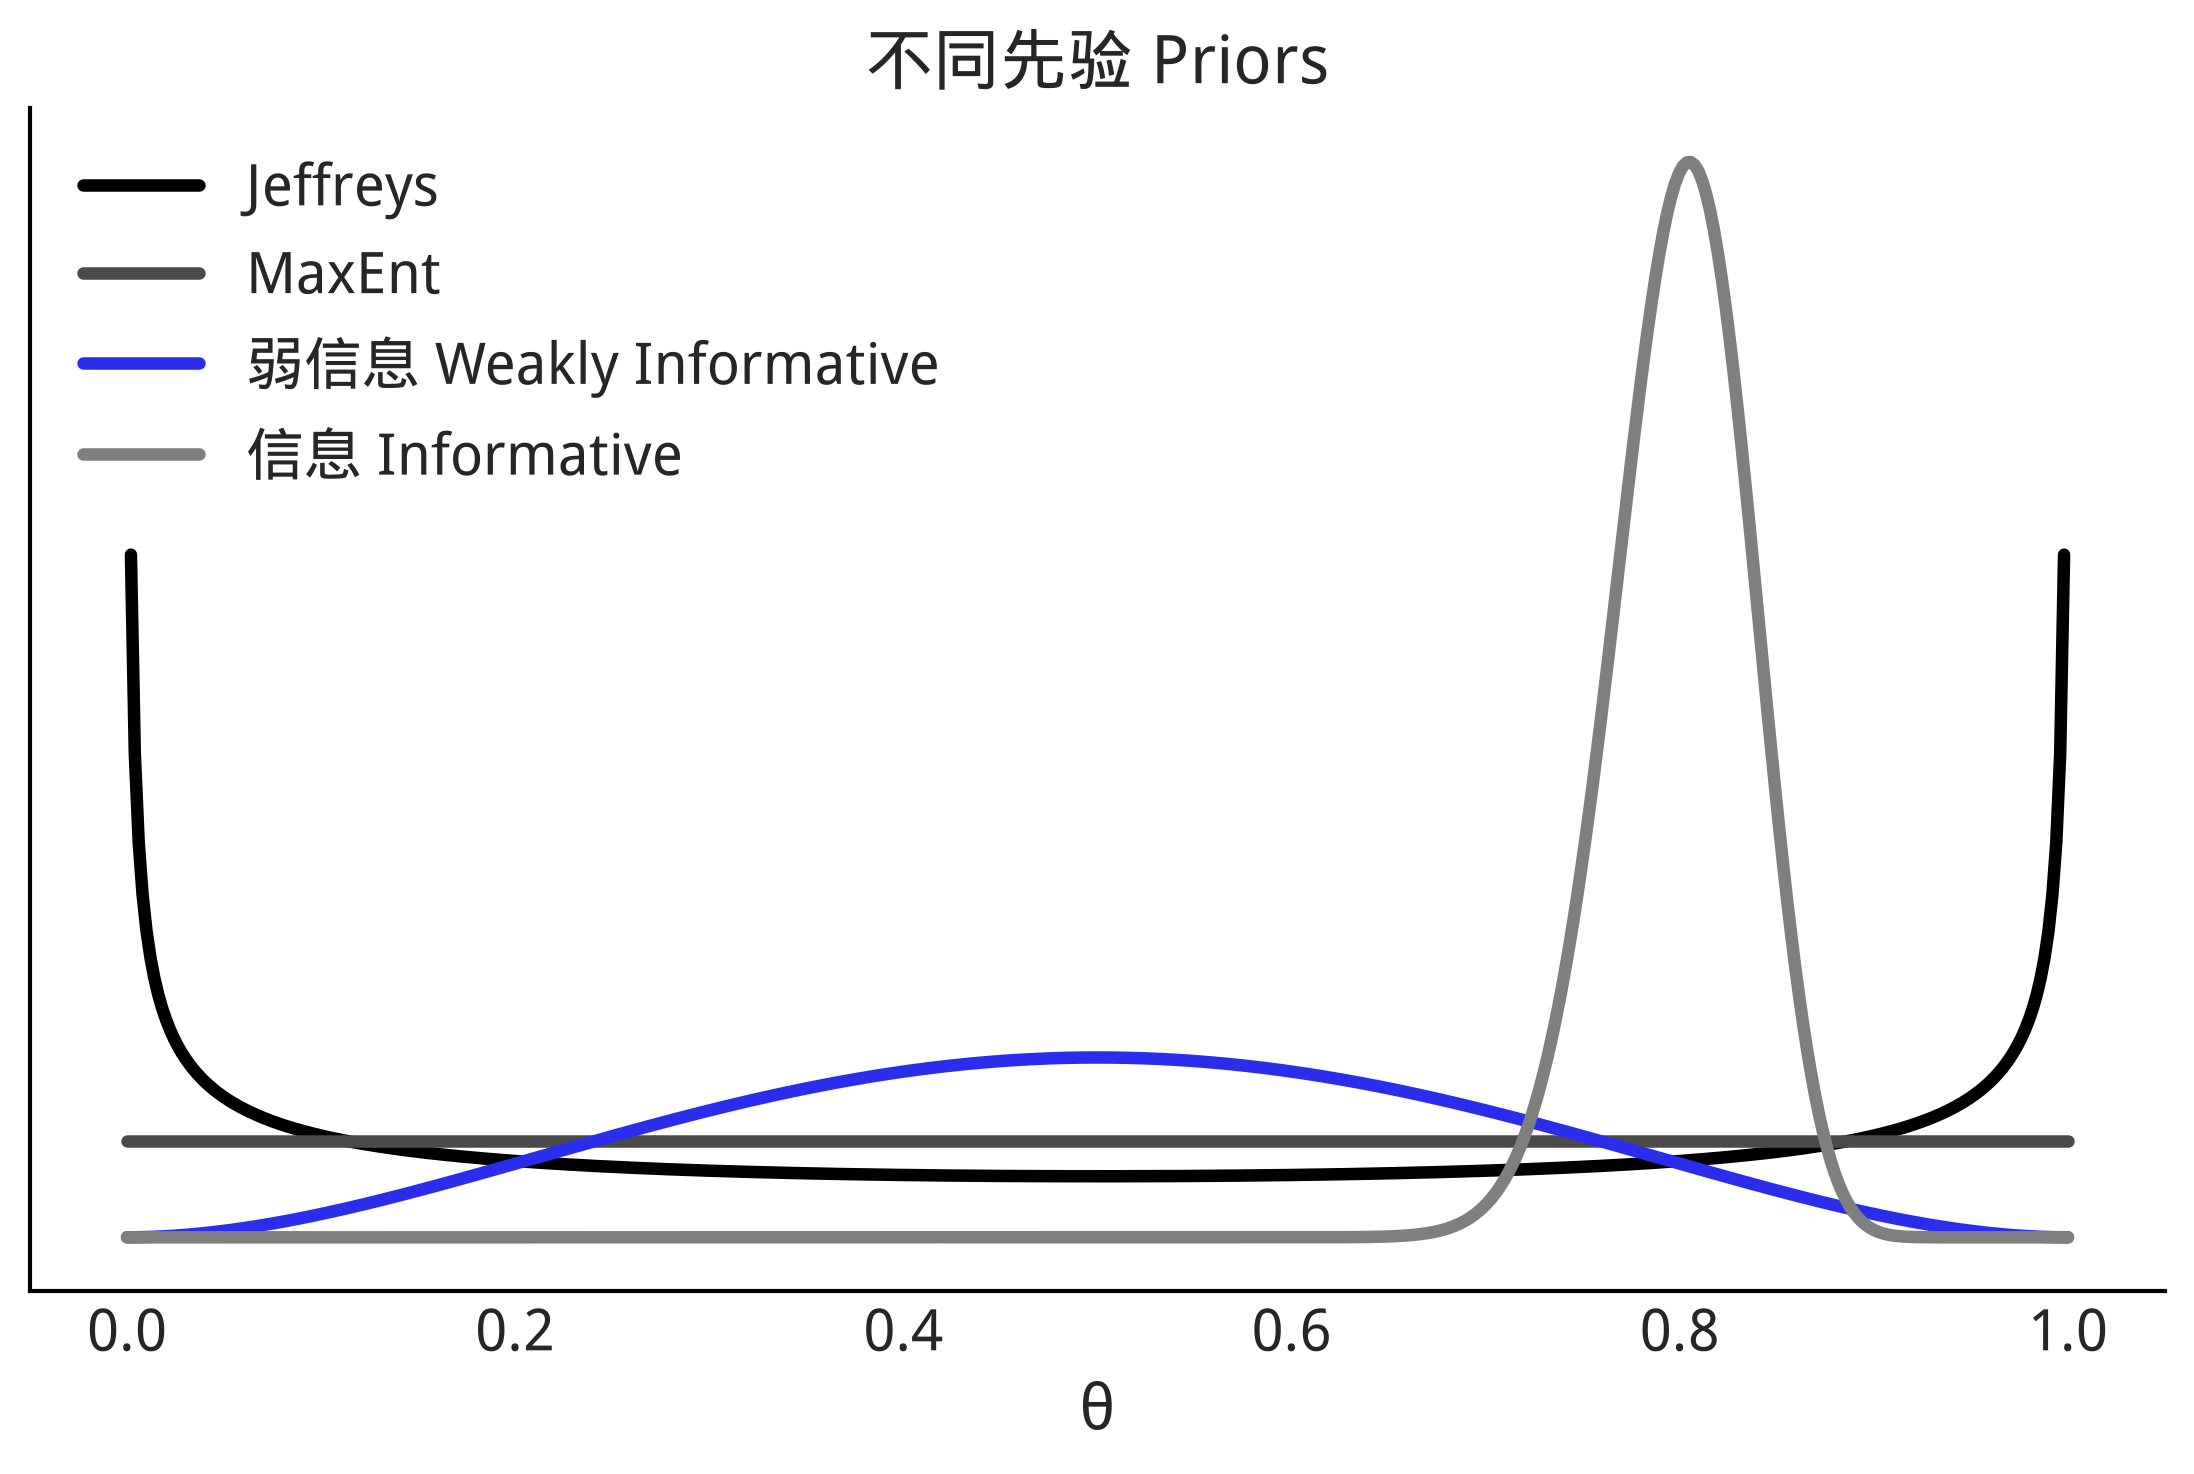

In [21]:
x = np.linspace(0, 1, 500)
params = [(0.5, 0.5), (1, 1), (3, 3), (100, 25)]

labels = ["Jeffreys", "MaxEnt", "弱信息 Weakly Informative",
          "信息 Informative"]

_, ax = plt.subplots()
for (α, β), label, c in zip(params, labels, (0, 1, 4, 2)):
    pdf = stats.beta.pdf(x, α, β)
    ax.plot(x, pdf, label=f"{label}", c=f"C{c}", lw=3)
    ax.set(yticks=[], xlabel="θ", title="不同先验 Priors")
    ax.legend()
plt.savefig("img/chp01/prior_informativeness_spectrum.png")



弱信息先验能够把后验分布约束在一个合理的范围内,因此也被称为**正则化先验
(regularizing priors)**。正则化是一种通过添加信息来求解病态问题、或降低过拟合风险的
手段,而先验恰好提供了一种有原则的方式来实现正则化。

> **过拟合**:当一个模型给出的预测非常贴近用来拟合它的(有限)数据集,但对新数据和/或
> 未来观测的预测效果很差时,就发生了过拟合——也就是说,模型无法把预测能力推广到更广泛的
> 可能观测集合上。过拟合的反面是欠拟合,即模型未能充分捕捉数据背后的结构。我们会在后续
> 讨论模型比较和信息准则的章节里详细讨论这些话题。

本书中,我们大多数情况下会使用弱信息先验。有时候先验的使用不会有太多论证,单纯是因为
示例的重点在于贝叶斯建模工作流的其他方面。但我们也会展示一些用先验预测检验来帮助校准
先验的例子。

### 用先验预测分布评估先验

在评估先验选择是否合理时,前面提到的先验预测分布是一个很好用的工具。通过从先验预测分布
中采样,计算机帮我们把参数空间里的选择,翻译成了观测变量空间里的样本。用观测值的语言来
思考问题,通常比用模型参数的语言思考更容易,这也让模型评估变得更简单。以 Beta-Binomial
模型为例,先验预测分布让我们不必去判断"某个具体的 $\theta$ 值是否合理",而是可以直接判断
"某个具体的成功次数是否合理"。对于参数经过多次数学变换、或者多个先验相互作用的复杂模型
而言,这种做法会更加有用。最后,计算先验预测分布还能帮助我们确认模型是否被正确地写出来、
是否能够在我们使用的概率编程语言中正常运行,甚至有助于调试模型。在后续章节中,我们会看到
更多具体的例子,展示如何依据先验预测样本进行推理,并用它们来选择合理的先验。



## 习题

题目按难度标注为 易(E)、中(M)、难(H)。完整题目见原书英文版(`markdown/chp_01.md`
第 1375 行起)。这里列出全部题目的中文翻译,供读者练习:

**1E1.** 正如前文所讨论的,模型是用来帮助定义和理解某个对象或过程的人工表征。然而,没有
任何模型能够完美复刻它所代表的事物,因此总会在某些方面存在不足。本书聚焦于一类特定的
模型——统计模型。你还能想到哪些其他类型的模型?它们是如何帮助人们理解被建模对象的?又
存在哪些不足?

**1E2.** 把下面这些用语言描述的说法,分别对应到正确的数学表达式:
1. 在给定观测数据条件下,参数的概率
2. 在看到任何数据之前,参数的分布
3. 在给定参数取值条件下,观测数据的合理程度(似然)
4. 在给定观测数据条件下,未见观测值的概率
5. 在看到任何数据之前,未见观测值的概率

**1E3.** 下列表达式中,哪一个对应"在已知是 1816 年 7 月 9 日这天的条件下,天气晴朗的
概率"这句话?
1. $p(\text{晴朗})$
2. $p(\text{晴朗} \mid \text{7 月})$
3. $p(\text{晴朗} \mid \text{1816 年 7 月 9 日})$
4. $p(\text{1816 年 7 月 9 日} \mid \text{晴朗})$
5. $p(\text{晴朗}, \text{1816 年 7 月 9 日}) / p(\text{1816 年 7 月 9 日})$

**1E4.** 证明"随机挑选一个人恰好是教皇的概率",与"教皇恰好是人类的概率"并不是一回事。
在动画剧集《飞出个未来》(Futurama)里,(太空)教皇是一只爬行动物。这会如何改变你前面
的计算?

**1E5.** 为以下场景勾勒出可能的观测值分布形状:
1. 假设服从泊松分布,你家附近咖啡馆每天的顾客数量
2. 假设服从均匀分布,成年犬的体重(千克)
3. 假设服从正态分布,成年大象的体重(千克)
4. 假设服从偏正态分布,成年人的体重(磅)

**1E6.** 针对上一题的每种情形,用 SciPy 指定对应的分布(Python 代码)。选择你认为合理
的参数,抽取 1000 个随机样本并画出分布。这个分布结合你的领域知识来看是否合理?如果不
合理,调整参数并重复这个过程,直到看起来合理为止。

**1E7.** 比较先验 $\text{Beta}(0.5, 0.5)$、$\text{Beta}(1, 1)$、$\text{Beta}(1, 4)$。
这些先验在形状上有什么区别?

**1E8.** 重新运行前面"共轭先验"一节中更新先验的那段代码,但换成你自己选择的两个 Beta
先验。提示:可以尝试 $\alpha \neq \beta$ 的先验,比如 $\text{Beta}(2, 5)$。

**1E9.** 试着构造新的约束条件,得到新的最大熵分布(参考"最大熵先验"一节的代码)。

**1E10.** 在我们自己实现的 Metropolis-Hastings 采样器中,修改 `can_sd` 的值并重新运行。
可以试试 0.001 和 1 这样的取值。
1. 计算均值、标准差和 HDI,和书中用 `can_sd=0.05` 算出的结果对比,差异有多大?
2. 用 `az.plot_posterior` 函数画出结果。

**1E11.** 你需要估计蓝鲸、人类和老鼠的体重。假设它们都服从正态分布,并且你为方差设置
了相同的先验 $\mathcal{HN}(200\text{kg})$(半正态分布)。这个先验对成年蓝鲸而言属于哪种
类型——强信息、弱信息、还是无信息?对老鼠和人类呢?先验信息量的强弱,与我们对这些动物的
真实直觉之间是什么关系?

**1E12.** 使用下面这个函数,探索不同的先验组合(改变参数 `a` 和 `b`)与数据组合(改变
`heads` 和 `trials`),总结你的观察。

```python
def posterior_grid(grid=10, a=1, b=1, heads=6, trials=9):
    grid = np.linspace(0, 1, grid)
    prior = stats.beta(a, b).pdf(grid)
    likelihood = stats.binom.pmf(heads, trials, grid)
    posterior = likelihood * prior
    posterior /= posterior.sum()
    _, ax = plt.subplots(1, 3, sharex=True, figsize=(16, 4))
    ax[0].set_title(f"heads = {heads}\ntrials = {trials}")
    for i, (e, e_n) in enumerate(zip(
            [prior, likelihood, posterior],
            ["prior", "likelihood", "posterior"])):
        ax[i].set_yticks([])
        ax[i].plot(grid, e, "o-", label=e_n)
        ax[i].legend(fontsize=14)
```

**1E13.** 先验、先验预测、后验、后验预测这四种分布中,哪一种(或哪几种)可以用来回答
以下问题(部分问题可能对应多个答案)?
1. 在看到任何数据之前,我们认为参数值的分布是什么样的?
2. 在看到任何数据之前,我们认为可能观测到哪些取值?
3. 用模型估计出参数之后,我们预测接下来会观测到什么?
4. 在对观测数据做条件化之后,哪些参数值能够解释这些观测数据?
5. 可以用来计算参数的数值汇总统计量(比如均值)的是哪一种?
6. 可以用来可视化最高密度区间(HDI)的是哪一种?

**1M14.** 后验公式的分母中含有边际似然,这一项难以计算。而在"正比于"形式的贝叶斯定理
里,我们展示了:只要知道后验"相差一个比例常数",就足以完成推断。请说明,为什么
Metropolis-Hastings 方法的运行并不需要用到边际似然。提示:这是一道纸笔推导题,试着展开
接受概率的公式。

**1M15.** 在下面这个概率模型的定义中,指出哪部分是先验、哪部分是似然、哪部分是后验:

$$
\begin{split}
Y \sim \mathcal{N}(\mu, \sigma)\\
\mu \sim \mathcal{N}(0, 1)\\
\sigma \sim \mathcal{HN}(1)\\
\end{split}
$$

**1M16.** 在上面这个模型中,后验会有多少个参数?把你的答案和抛硬币问题(Beta-Binomial
模型)中的模型对比一下。

**1M17.** 假设我们有两枚硬币:抛第一枚硬币时,一半概率正面一半概率反面。另一枚是一枚
被做过手脚的硬币,永远正面朝上。如果我们随机选一枚硬币抛出,结果是正面,那么这枚硬币是
被做过手脚的那枚的概率是多少?

**1M18.** 修改前面生成随机样本的代码,改为从一个你自选参数的泊松分布中生成随机样本。
然后修改 `post` 函数和 Metropolis-Hastings 采样代码,用 MCMC 样本估计你选定的参数。测试
样本数量、MCMC 迭代次数和初始起点,分别如何影响收敛到你所选真实参数的过程。

**1M19.** 假设我们要建一个模型,估计成年人身高(单位:厘米)的均值和标准差。以
Beta-Binomial 模型的 PyMC 代码为起点,按需修改似然和先验。完成之后:
1. 从先验预测分布中采样,生成先验预测分布的可视化图和数值汇总。
2. 用 (a) 的结果来论证你对先验和似然的选择是否合理。

**1M20.** 根据领域知识,你知道某个参数不能为负,均值大致在 3 到 10 个单位之间,标准差
大约是 2。用 Python 找出两个满足这些约束条件的先验分布。这可能需要通过反复抽样、并结合
图形和数值汇总来验证是否满足这些标准。

**1M21.** 某商店某天有 $n$ 位顾客光临。发生购买行为的顾客数 $Y$ 服从
$\text{Bin}(n, \theta)$ 分布,其中 $\theta$ 是顾客发生购买行为的概率。假设我们已知
$\theta$,并且 $n$ 的先验是 $\text{Pois}(4.5)$。
1. 用 PyMC 计算 $Y \in \{0, 5, 10\}$ 与 $\theta \in \{0.2, 0.5\}$ 所有组合下,$n$ 的
   后验分布,并用 `az.plot_posterior` 把结果画在同一幅图中。
2. 总结 $Y$ 和 $\theta$ 对后验的影响。

**1H22.** 修改生成随机数据的代码,改为从一个正态分布中生成样本,并记下你为均值和标准差
选择的参数。然后修改采样代码,从这个正态分布模型中采样,看看是否能恢复出你选定的参数。

**1H23.** 建一个模型,估计你所在地区晴天与阴天天数的比例。用你过去 5 天的个人观察数据。
思考一下数据采集过程:回忆过去 5 天有多难?如果需要过去 30 天的数据呢?过去一年呢?为
你选择的先验做出论证。得到一个估计晴天/阴天比例的后验分布,并对未来 10 天的天气做出预测。
用数值汇总和可视化两种方式来表达你的答案。

**1H24.** 你种了 12 株幼苗,其中 3 株发芽了。设 $\theta$ 为幼苗发芽的概率,假设 $\theta$
的先验是 $\text{Beta}(1, 1)$。
1. 用纸笔计算后验均值和标准差,再用 SciPy 验证你的计算。
2. 用 SciPy 计算 94% 的等尾区间和最高密度区间。
3. 用 SciPy 计算:如果再种 12 株幼苗,至少有一株发芽的后验预测概率。

在用 SciPy 完成上述计算后,请再用 PyMC 和 ArviZ 重复一遍这个练习。



## 脚注

[^1]: 如果想说得更宽泛一些,甚至可以说万事万物都是一个概率分布——只不过对于那些我们
    假定能以任意精度确切知道的量,这个分布是一个狄拉克 δ 函数。

[^2]: 有些学者把这类量称为潜变量(latent variables),而把"参数"这个名字留给那些固定
    但未知的量。

[^3]: 你也可以换个角度,从确定性或信息量的角度来理解这一点——取决于你是"半杯水是空的"
    还是"半杯水是满的"那种性格。

[^4]: 有时"分布"这个词会被省略,在讨论这些话题时这种省略很常见。

[^5]: 这里的"实验"是广义的,指任何采集或生成数据的流程。

[^6]: 参见 <https://xkcd.com/2117/> 这幅关于积分的漫画。

[^7]: 严格来说应该讨论的是随机变量的期望。

[^8]: 参见马尔可夫链与 Metropolis-Hastings 相关章节中关于细致平衡(detailed balance)
    的讨论。

[^9]: 关于推断方法更详尽的讨论,建议阅读原书相关章节及其参考文献。

[^10]: 在其他通用推断引擎中,这有时也被称为"核"(kernel)。

[^11]: 你也可以用 ArviZ 的 `plot_trace` 函数得到类似的图,本书后续都会这样做。

[^12]: 注意,原则上包含给定比例总密度的区间有无穷多个。

[^13]: 更多例子可参见维基百科的共轭先验分布表。

[^14]: 除了那些发生在你脑子里的计算之外。

[^15]: 举例来说,带 L2 正则化的线性回归,等价于对回归系数使用高斯先验。

[^16]: 举例来说,如果我们有 $\theta$ 的后验样本,就可以把这些样本代入
    $\kappa = \frac{\theta}{1-\theta}$ 直接算出对应的 $\kappa$ 样本。

[^17]: 参见维基百科"似然原理"(Likelihood principle)词条。

[^18]: 参见前文关于"熵"的讨论。

[^19]: 维基百科"最大熵概率分布"词条中有更长的列表。

[^20]: 即便这类先验的严格定义需要比这里所给的更多语境,我们依然认为这个例子能传达一种
    有用的直觉,并会随着阅读本书的深入而不断被细化。
